# NLP - Project 1 - Benjamin Amhof

## Introduction

**Task:** Physical commonsense question answering on the [PIQA dataset](https://huggingface.co/datasets/ybisk/piqa)
**Two architectures required:**
1. Word embeddings (word2vec / GloVe / fastText) + 2-layer classifier with ReLU
2. 2-layer RNN (LSTM or GRU) + same word embeddings (from arch 1) + 2-layer classifier — trained end-to-end.

**Links to Results:**
- Weights and Biases: https://api.wandb.ai/links/benjamin-amhof-hochschule-luzern/bnqm3tes (you can select the different sweeps/runs with the filter below the visuals in the report)

**AI Tools used:**
- Gemini: Sparring Partner
- Github Copilot: Code completion
- Claude Sonnet 4.6: NLP Advisor
- Claude Code: Code improvements and bugfixes
- Claude Code: Improving md cells in Notebook

## Setup

In [ ]:
import subprocess, sys
pkgs = [
    "datasets",
    "gensim",
    "nltk",
    "torch",         
    "wandb",
    "scikit-learn",
    "matplotlib",
]
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + pkgs)
print("All packages installed.")

All packages installed.


In [2]:
import os, math, random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence
import wandb

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print(f"Seeds set to {SEED}")

Seeds set to 42


In [3]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Device: CUDA  ({torch.cuda.get_device_name(0)})")
    print(f"VRAM:   {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Device: Apple Silicon MPS")
else:
    device = torch.device("cpu")
    print("Device: CPU")

Device: CUDA  (NVIDIA A16)
VRAM:   15.6 GB


## Preprocessing

### Data Loading

In [4]:
from datasets import load_dataset

In [ ]:
train = load_dataset("ybisk/piqa", split="train[:-1000]", revision="refs/convert/parquet")
valid = load_dataset("ybisk/piqa", split="train[-1000:]", revision="refs/convert/parquet")
test  = load_dataset("ybisk/piqa", split="validation",   revision="refs/convert/parquet")

In [6]:
# Exploration of the dataset
print("--- Split sizes ---")
print(f"{len(train)=}  |  {len(valid)=}  |  {len(test)=}")

print("\n--- Features ---")
print(train.features)

INDEX_EXAMPLE_1 = 0
INDEX_EXAMPLE_2 = 49
INDEX_EXAMPLE_3 = 200

print("\n--- Raw Examples ---")
print(train[INDEX_EXAMPLE_1])
print(train[INDEX_EXAMPLE_2])
print(train[INDEX_EXAMPLE_3])

--- Split sizes ---
len(train)=15113  |  len(valid)=1000  |  len(test)=1838

--- Features ---
{'goal': Value('string'), 'sol1': Value('string'), 'sol2': Value('string'), 'label': ClassLabel(names=['0', '1'])}

--- Raw Examples ---
{'goal': "When boiling butter, when it's ready, you can", 'sol1': 'Pour it onto a plate', 'sol2': 'Pour it into a jar', 'label': 1}
{'goal': 'To prevent eye infections,', 'sol1': 'replace your mascara with a new tube every three months.', 'sol2': 'replace your mascara with a new shade every three months.', 'label': 0}
{'goal': 'To clean off rust from a metal table that was resistant to vinegar.', 'sol1': 'Use a soft bristle brush.', 'sol2': 'Use a stiff metal bristle brush.', 'label': 1}


In [7]:
print("\n--- A few examples ---")
for i in [INDEX_EXAMPLE_1, INDEX_EXAMPLE_2, INDEX_EXAMPLE_3]:
    ex = train[i]
    correct = ex["sol1"] if ex["label"] == 0 else ex["sol2"]
    wrong   = ex["sol2"] if ex["label"] == 0 else ex["sol1"]
    print(f"\n[{i}] Goal:    {ex['goal']}")
    print(f"     Correct: {correct}")
    print(f"     Wrong:   {wrong}")


--- A few examples ---

[0] Goal:    When boiling butter, when it's ready, you can
     Correct: Pour it into a jar
     Wrong:   Pour it onto a plate

[49] Goal:    To prevent eye infections,
     Correct: replace your mascara with a new tube every three months.
     Wrong:   replace your mascara with a new shade every three months.

[200] Goal:    To clean off rust from a metal table that was resistant to vinegar.
     Correct: Use a stiff metal bristle brush.
     Wrong:   Use a soft bristle brush.


### Preprocessing Decisions

In [8]:
import re
import nltk
import collections
import numpy as np
import matplotlib.pyplot as plt

nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

STOPWORDS = set(stopwords.words("english"))

#### Format Cleaning

**Why**: Word embeddings like GloVe or word2vec use a fixed vocabulary; HTML artifacts like `&amp;` or `\xa0` map to `<UNK>` tokens, wasting representational capacity. Cleaning them ensures inputs align with the embedding vocabulary. I also check for non-ASCII characters since some embedding vocabularies are ASCII-only.

**Decision:** No format cleaning needed — the dataset is already clean.
- `html_tag_pattern`: none found.
- `html_entity_pattern`: none found (the 2× "&M" were false positives from "M&Ms").
- `non_ascii_pattern`: a small number of occurrences; rather than stripping them, I choose an embedding model (FastText) that is not ASCII-limited.
- `control_char_pattern`: none found.

In [9]:
# Scan the train set for special characters and HTML artifacts

FIELDS = ("goal", "sol1", "sol2")

html_tag_pattern     = re.compile(r"<[^>]+>")
html_entity_pattern  = re.compile(r"&(?:#\d+|#x[\da-fA-F]+|[a-zA-Z]+);")
non_ascii_pattern    = re.compile(r"[^\x00-\x7F]")
control_char_pattern = re.compile(r"[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]")

found = {
    "html_tags":     collections.Counter(),
    "html_entities": collections.Counter(),
    "non_ascii":     collections.Counter(),
    "control_chars": collections.Counter(),
}
patterns = {
    "html_tags":     html_tag_pattern,
    "html_entities": html_entity_pattern,
    "non_ascii":     non_ascii_pattern,
    "control_chars": control_char_pattern,
}

for ex in train:
    for field in FIELDS:
        text = ex[field]
        for category, pattern in patterns.items():
            for match in pattern.findall(text):
                found[category][match] += 1

for category, counter in found.items():
    print(f"{category}: {sum(counter.values())} total occurrence(s), {len(counter)} unique")
    for char, count in counter.most_common(10):
        print(f"  {repr(char):30s}  ×{count}")

html_tags: 0 total occurrence(s), 0 unique
html_entities: 2 total occurrence(s), 1 unique
  '&Ms;'                          ×2
non_ascii: 993 total occurrence(s), 32 unique
  '’'                             ×380
  '°'                             ×122
  '”'                             ×75
  '½'                             ×70
  '–'                             ×59
  '“'                             ×59
  'é'                             ×45
  '—'                             ×33
  '•'                             ×28
  '¼'                             ×26
control_chars: 0 total occurrence(s), 0 unique


#### Establish Benchmark

I compare OOV rates across all three pretrained embeddings after each preprocessing stage. I retain only the vocabulary index from each model to avoid holding multiple large embedding matrices in memory simultaneously.

Note: The FastText OOV rate computed via vocabulary lookup is an overestimate — FastText generates subword-based vectors at runtime for tokens not in its explicit vocabulary. The true OOV rate (measured via `get_vector()`) is reported separately.

In [10]:
# Establish train vocabulary (raw, no preprocessing)
def get_train_tokens(dataset, n=None):
    n = n or len(dataset)
    tokens = set()
    for i in range(n):
        ex = dataset[i]
        for key in ["goal", "sol1", "sol2"]:
            tokens.update(word_tokenize(ex[key]))
    return tokens

train_vocab = get_train_tokens(train)
print(f"Train vocabulary size (raw): {len(train_vocab):,}")

Train vocabulary size (raw): 18,762


In [11]:
import gensim.downloader as api

EMBEDDING_KEYS = {
    "GloVe":    "glove-wiki-gigaword-300",
    "Word2Vec": "word2vec-google-news-300",
    "FastText": "fasttext-wiki-news-subwords-300",
}
_vocab_cache = {}

def get_embedding_vocab(name):
    if name not in _vocab_cache:
        print(f"Loading {name} vocab...")
        model = api.load(EMBEDDING_KEYS[name])
        _vocab_cache[name] = set(model.key_to_index.keys())
        del model
    return _vocab_cache[name]

def print_oov_stats(tokens):
    """Print OOV % for each embedding model."""
    vocab = set(tokens)
    for name in EMBEDDING_KEYS:
        emb_vocab = get_embedding_vocab(name)
        oov = vocab - emb_vocab
        pct = 100 * len(oov) / len(vocab) if vocab else 0
        print(f"{name}: {pct:.2f}% OOV ({len(oov)}/{len(vocab)})")
        print(f"  Sample OOV: {list(oov)[:8]}")

print("=== Benchmark Baseline ===")
print_oov_stats(train_vocab)

=== Benchmark Baseline ===
Loading GloVe vocab...
GloVe: 29.59% OOV (5551/18762)
  Sample OOV: ['frozen,1', 'Opening', 'Half', 'Out', 'S', 'waterskin', 'Have', 'Miss']
Loading Word2Vec vocab...
Word2Vec: 12.77% OOV (2396/18762)
  Sample OOV: ['frozen,1', '3-in-1', 'cranberry-apple', 'kosher/sea', 'sheet.', 'OldVersion.com', 'water.Cap', 'waterbath']
Loading FastText vocab...
FastText: 8.13% OOV (1526/18762)
  Sample OOV: ['frozen,1', 'cranberry-apple', 'kosher/sea', 'OldVersion.com', 'water.Cap', 'waterbath', 'nutella-berry', 'pad.Dampen']


#### Tokenisation

**Decision:** Use `nltk.word_tokenize`.

**Why:** PIQA sentences contain contractions ("it's", "don't") and punctuation attached to words. `str.split()` would keep "word." as one token. `word_tokenize` handles these cases correctly and is the standard choice for English text preprocessing.

#### Lowercasing, Stemming, Lemmatizing, Stopword/Punctuation Removal

All of these were applied individually and in combination, then compared across all three embedding vocabularies using OOV rate as the objective metric.

**Lowercasing — No (globally).**
GloVe OOV improves (29.65% → 11.78%), but Word2Vec OOV actually worsens (12.74% → 15.40%) — the effect is model-dependent. Lowercasing is applied selectively at embedding lookup time for tokens that are OOV in their original form, recovering sentence-initial capitals (e.g., "Emulsifying" → "emulsifying") without destroying meaningful capitalisation elsewhere.

**Stemming — No.**
Catastrophically increases OOV across all models (FastText: 8.15% → 36.07%, Word2Vec: 12.74% → 42.46%). PIQA's physical action verbs ("scrubbing", "mixing") are semantically critical — stemming reduces them to fragments with no pretrained embedding. Also excluded by course constraint.

**Lemmatization — No.**
Increases OOV across all models (GloVe: 29.65% → 32.92%, FastText: 8.15% → 9.04%). Verb forms like "melting", "melted", "scraped" carry distinct meaning about process stages — reducing them to base forms loses task-relevant information.

**Stopword removal — No.**
Prepositions and function words encode the physical spatial relations that discriminate correct from incorrect solutions — "into" vs "onto", "under" vs "above" are task-critical. No OOV benefit (FastText remains ~8.20%).

**Punctuation removal — No.**
No meaningful OOV impact (FastText: 8.15% → 8.15%). Compound terms like "9.5-inch" and "dye-free" rely on punctuation for integrity. For the RNN, punctuation serves as an implicit boundary signal in multi-step procedural instructions.

In [12]:
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.corpus import stopwords
import string

stemmer    = PorterStemmer()
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

In [13]:
# Lowercasing
lowercased = [word.lower() for word in train_vocab]
print("=== Lowercasing ===")
print_oov_stats(lowercased)

=== Lowercasing ===
GloVe: 11.74% OOV (1853/15782)
  Sample OOV: ['frozen,1', 'scrunchies', 'envelop.folding', 'cranberry-apple', 'd.i.y', '-wedding', 'sheet.', 'kosher/sea']
Word2Vec: 15.36% OOV (2424/15782)
  Sample OOV: ['frozen,1', '3-in-1', 'hersey', 'envelop.folding', 'cranberry-apple', 'd.i.y', '-wedding', 'sheet.']
FastText: 9.70% OOV (1531/15782)
  Sample OOV: ['frozen,1', 'hersey', 'envelop.folding', 'cranberry-apple', 'd.i.y', '-wedding', 'kosher/sea', 'waterbath']


In [14]:
# Punctuation removal
punct_removal = [t for t in train_vocab if t not in string.punctuation]
print("=== Punctuation removal ===")
print_oov_stats(punct_removal)

=== Punctuation removal ===
GloVe: 29.62% OOV (5551/18738)
  Sample OOV: ['frozen,1', 'Opening', 'Half', 'Out', 'S', 'waterskin', 'Have', 'Miss']
Word2Vec: 12.71% OOV (2382/18738)
  Sample OOV: ['frozen,1', '3-in-1', 'cranberry-apple', 'kosher/sea', 'sheet.', 'OldVersion.com', 'water.Cap', 'waterbath']
FastText: 8.14% OOV (1525/18738)
  Sample OOV: ['frozen,1', 'cranberry-apple', 'kosher/sea', 'OldVersion.com', 'water.Cap', 'waterbath', 'nutella-berry', 'pad.Dampen']


In [15]:
# Stopword removal
stop_w_removal = [t for t in train_vocab if t not in stop_words]
print("=== Stopword removal ===")
print_oov_stats(stop_w_removal)

=== Stopword removal ===
GloVe: 29.80% OOV (5551/18629)
  Sample OOV: ['frozen,1', 'Opening', 'Half', 'Out', 'S', 'waterskin', 'Have', 'Miss']
Word2Vec: 12.84% OOV (2392/18629)
  Sample OOV: ['frozen,1', '3-in-1', 'cranberry-apple', 'kosher/sea', 'sheet.', 'OldVersion.com', 'water.Cap', 'waterbath']
FastText: 8.19% OOV (1526/18629)
  Sample OOV: ['frozen,1', 'cranberry-apple', 'kosher/sea', 'OldVersion.com', 'water.Cap', 'waterbath', 'nutella-berry', 'pad.Dampen']


In [16]:
# Stemming
stemmed = [stemmer.stem(t) for t in train_vocab]
print("=== Stemming ===")
print_oov_stats(stemmed)

=== Stemming ===
GloVe: 38.00% OOV (4197/11044)
  Sample OOV: ['frozen,1', 'unrol', 'duck-tap', 'firmly.low', 'nutcrack', 'chlorin', 'cap.plac', 'cheesgrat']
Word2Vec: 42.43% OOV (4686/11044)
  Sample OOV: ['frozen,1', 'unrol', 'duck-tap', 'firmly.low', '3-in-1', 'nutcrack', 'hersey', 'chlorin']
FastText: 36.07% OOV (3984/11044)
  Sample OOV: ['frozen,1', 'unrol', 'duck-tap', 'firmly.low', 'nutcrack', 'hersey', 'cap.plac', 'cheesgrat']


In [17]:
# Lemmatization
lemmatized = [lemmatizer.lemmatize(t) for t in train_vocab]
print("=== Lemmatization ===")
print_oov_stats(lemmatized)

=== Lemmatization ===
GloVe: 32.89% OOV (5540/16844)
  Sample OOV: ['frozen,1', 'Opening', 'Half', 'Out', 'S', 'waterskin', 'Have', 'Miss']
Word2Vec: 14.15% OOV (2383/16844)
  Sample OOV: ['frozen,1', '3-in-1', 'cranberry-apple', 'kosher/sea', 'sheet.', 'OldVersion.com', 'water.Cap', 'waterbath']
FastText: 9.03% OOV (1521/16844)
  Sample OOV: ['frozen,1', 'cranberry-apple', 'kosher/sea', 'OldVersion.com', 'water.Cap', 'waterbath', 'nutella-berry', 'pad.Dampen']


In [18]:
# All together — combined effect
lowercased    = [word.lower() for word in train_vocab]
punct_removal = [t for t in lowercased if t not in string.punctuation]
stop_w_removal = [t for t in punct_removal if t not in stop_words]
lemmatized    = [lemmatizer.lemmatize(t) for t in stop_w_removal]
print("=== All combined ===")
print_oov_stats(lemmatized)

=== All combined ===
GloVe: 13.47% OOV (1839/13649)
  Sample OOV: ['frozen,1', 'scrunchies', 'envelop.folding', 'cranberry-apple', 'd.i.y', '-wedding', 'sheet.', 'kosher/sea']
Word2Vec: 17.51% OOV (2390/13649)
  Sample OOV: ['frozen,1', '3-in-1', 'hersey', 'envelop.folding', 'cranberry-apple', 'd.i.y', '-wedding', 'sheet.']
FastText: 11.12% OOV (1518/13649)
  Sample OOV: ['frozen,1', 'hersey', 'envelop.folding', 'cranberry-apple', 'd.i.y', '-wedding', 'kosher/sea', 'waterbath']


In [19]:
# True FastText OOV — via get_vector() since subword n-grams mean vocab lookup overestimates OOV
def get_real_fasttext_oov(tokens, model=None):
    if model is None:
        print("Loading FastText model...")
        model = api.load("fasttext-wiki-news-subwords-300")
    oov = []
    for t in tokens:
        try:
            _ = model.get_vector(t)
        except KeyError:
            oov.append(t)
    pct = 100 * len(oov) / len(tokens) if tokens else 0
    print(f"FastText (true OOV via get_vector): {pct:.2f}% ({len(oov)}/{len(tokens)})")
    print(f"  Sample OOV: {oov[:10]}")
    return pct, oov

get_real_fasttext_oov(list(train_vocab))

Loading FastText model...
FastText (true OOV via get_vector): 8.13% (1526/18762)
  Sample OOV: ['frozen,1', 'waterskin', 'opitcal', 'gallon-', 'beanie/hat/toque', "'pink", 'recyclable\xad', 'shrin', 'Moisturize', 'defrozen']


(8.133461251465729,
 ['frozen,1',
  'waterskin',
  'opitcal',
  'gallon-',
  'beanie/hat/toque',
  "'pink",
  'recyclable\xad',
  'shrin',
  'Moisturize',
  'defrozen',
  'six-quarters',
  'vasing',
  'unpitted',
  'block.Then',
  'linemint',
  'Minature',
  'danging',
  'organges',
  'swallwtail',
  'rice-like',
  'shrimplets',
  'semi-ripe',
  '7/32nd',
  'irigate',
  'Precision/Small',
  'carerr',
  'acylic',
  '400°F',
  'playdoh',
  'hand-soap',
  'liking.Mix',
  'Tenderize',
  'walls.Then',
  'Xacto',
  'Hjaelp',
  "'return",
  'Larabar',
  '2″',
  '3/16th',
  'Needle-felt',
  'glue.Let',
  'stain-causing',
  'wide-toothed',
  'tablespoonds',
  'measurementi',
  '1-1/4',
  'xacto',
  'Refold',
  'down.Cover',
  'rubber.Allow',
  'weatherworn',
  'grass-produced',
  'papertowl',
  'stepstool',
  'Quiddich',
  'griner',
  'large/thick',
  'Pier/Shelves',
  'kilz',
  'giftbasket',
  'sugar-egg',
  'whiste',
  'kindeling',
  'SQ3',
  'squegee',
  '8oz/225g',
  'deglazed',
  '180-grit

#### Removal of Unknown/Other Words

**Decision:** Keep OOV tokens: map them to a shared `<UNK>` vector rather than removing them.

In PIQA, OOV tokens are frequently physically specific nouns and compound terms that the task centres on — silently dropping them would remove task-critical content. Mapping to `<UNK>` preserves the token's position in the sequence and signals its presence to the model, which is especially important for the RNN's sequential hidden state construction.

**UNK vector:** Mean of all in-vocabulary FastText embedding vectors. A mean UNK vector (norm ≈ 0.46) places unknown tokens in a neutral but non-zero position in embedding space, avoiding the representational collapse a zero vector would cause when averaging token embeddings.

#### Feature Selection

**Decision:** None. There are no auxiliary or redundant fields to reduce. Every available field (`goal`, `sol1`, `sol2`) carries task-critical information and is already accounted for in the input design. Feature selection as a noise-reduction step is not applicable here.

#### Input Format: How is data passed to the model?

**Decision:** Pairwise input format — two inputs per example: `[goal + sol1]` and `[goal + sol2]`.

Each is embedded separately:
- **Architecture 1:** averaged token vectors per field, then concatenated → 600-dim vector → classifier
- **Architecture 2:** each sequence passed through the GRU independently; final hidden states concatenated → classifier

A single sigmoid output scores each pair. At inference, the solution with the higher score is selected. This frames the task as it is intended: explicitly comparing two candidates against a shared physical goal. It also doubles the effective training pairs (30,226 from 15,113 examples), which is beneficial given PIQA's limited size.

#### Label Format: What should the model predict?

**Decision:** Binary label per pairwise input: `1` if the given solution is the correct one, `0` otherwise.

Each PIQA example has an original `label` ∈ {0, 1} indicating which solution is correct. From each example, two training pairs are created with complementary labels:
- `(goal, sol1)` → label = `1 - original_label` (1 if sol1 is correct)
- `(goal, sol2)` → label = `original_label` (1 if sol2 is correct)

This construction guarantees a perfectly balanced training set (exactly 50% positive labels) with no need for class weighting. The model learns to score each solution independently; at inference, both scores are computed and the higher one determines the prediction.

#### Truncation

**Decision:** Truncate to `MAX_SEQ_LEN = 128` tokens per field.

Data analysis shows a mean of 28.66 and median of 23 tokens per pairwise input, meaning truncation affects less than 1% of examples. The max of 453 tokens would otherwise dominate batch padding in the RNN. 128 (= 2⁷) covers the 99th percentile (108 tokens) with a small buffer, leaving nearly all examples fully intact without increasing computational cost.

Mean:           28.66
Median:         23
99th pct:       108
Max:            453
Truncated (<1%): 177 / 30226 examples


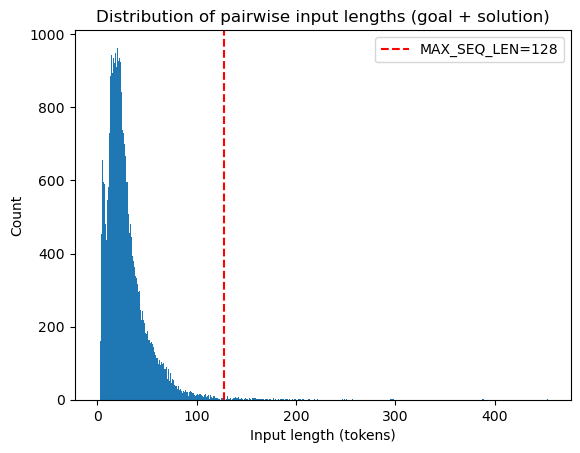

In [20]:
from nltk.tokenize import word_tokenize
import matplotlib.pyplot as plt
import numpy as np

def get_pairwise_lengths(dataset, n=None):
    n = n or len(dataset)
    lengths = []
    for i in range(n):
        ex = dataset[i]
        for sol in ["sol1", "sol2"]:
            text   = ex["goal"] + " " + ex[sol]
            tokens = word_tokenize(text)
            lengths.append(len(tokens))
    return lengths

lengths = get_pairwise_lengths(train)
print(f"Mean:           {np.mean(lengths):.2f}")
print(f"Median:         {np.median(lengths):.0f}")
print(f"99th pct:       {np.percentile(lengths, 99):.0f}")
print(f"Max:            {np.max(lengths)}")
print(f"Truncated (<1%): {sum(l > 128 for l in lengths)} / {len(lengths)} examples")

plt.hist(lengths, bins=range(0, max(lengths) + 2, 1))
plt.axvline(128, color="red", linestyle="--", label="MAX_SEQ_LEN=128")
plt.xlabel("Input length (tokens)")
plt.ylabel("Count")
plt.title("Distribution of pairwise input lengths (goal + solution)")
plt.legend()
plt.show()

#### Batching, Padding

- **Batch Size:** Binary search over a single forward/backward pass finds the hardware ceiling. With 30,226 effective training pairs, a practical batch size of 256 yields ≈118 batches/epoch — sufficient gradient update frequency without exceeding memory.

- **Padding:** Dynamic padding to the longest sequence within each batch. With a median pairwise length of 23 tokens, static padding to 128 would waste ≈82% of each sequence as padding. `pack_padded_sequence` ensures pad tokens do not influence the GRU hidden state.

- **Shuffling:** Applied each training epoch. Label distribution analysis shows the dataset is already well-balanced (50.1% positive overall, <1pp difference between halves), so shuffling has low impact on label balance but is applied as standard practice to prevent order-dependent learning.

- **Drop last batch:** Retained. The last batch contains ≈18 examples (0.06% of training data) — dropping it wastes training signal with no meaningful benefit to gradient stability.

- **Pairwise batching:** Both pairs from the same PIQA example are included in the same batch so their scores can be directly compared at inference.

In [21]:
# ── Device detection
import torch

if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Device: CUDA  ({torch.cuda.get_device_name(0)})")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Device: Apple Silicon MPS")
else:
    device = torch.device("cpu")
    print("Device: CPU")

Device: CUDA  (NVIDIA A16)


In [22]:
# ── Batch size binary search (MPS only — skipped on CUDA/CPU)
if torch.backends.mps.is_available():
    _mps = torch.device("mps")
    EMBED_DIM = 300

    def _test_batch(bs):
        try:
            x = torch.randn(bs, EMBED_DIM * 2).to(_mps)
            m = torch.nn.Sequential(torch.nn.Linear(EMBED_DIM*2, 256), torch.nn.ReLU(), torch.nn.Linear(256, 1)).to(_mps)
            m(x).sum().backward()
            del x, m; torch.mps.empty_cache()
            return True
        except RuntimeError:
            torch.mps.empty_cache(); return False

    lo, hi = 1, 4096
    while lo < hi:
        mid = (lo + hi + 1) // 2
        lo, hi = (mid, hi) if _test_batch(mid) else (lo, mid - 1)
    print(f"Max batch size on MPS: {lo}")
else:
    print(f"Skipped (device: {device}) — using BATCH_SIZE=256")

Skipped (device: cuda) — using BATCH_SIZE=256


In [23]:
# ── Padding waste analysis
goal_lens = [len(word_tokenize(x)) for x in train["goal"]]
sol_lens  = [len(word_tokenize(x)) for x in train["sol1"]]
pair_lens = [min(g + s, 128) for g, s in zip(goal_lens, sol_lens)]
waste     = (128 - np.median(pair_lens)) / 128 * 100
print(f"Median pairwise length: {np.median(pair_lens):.0f} tokens")
print(f"Static padding waste:   {waste:.1f}% per sequence → dynamic padding used")

Median pairwise length: 23 tokens
Static padding waste:   82.0% per sequence → dynamic padding used


In [24]:
# ── Shuffling — label balance check
labels = train["label"]
n = len(labels)
first_half_pos  = sum(labels[:n//2]) / (n//2) * 100
second_half_pos = sum(labels[n//2:]) / (n//2) * 100
overall_pos     = sum(labels) / n * 100
print(f"Overall:     {overall_pos:.1f}% positive")
print(f"First half:  {first_half_pos:.1f}%  |  Second half: {second_half_pos:.1f}%")
print(f"Difference:  {abs(first_half_pos - second_half_pos):.1f}pp")

Overall:     50.1% positive
First half:  50.5%  |  Second half: 49.8%
Difference:  0.7pp


In [25]:
# ── Drop last batch — data loss estimate
BATCH_SIZE        = 256
effective_train   = len(train) * 2   # each example → 2 pairwise inputs
last_batch_size   = effective_train % BATCH_SIZE
print(f"Effective training pairs: {effective_train:,}")
print(f"Last batch size:          {last_batch_size} ({last_batch_size/effective_train*100:.2f}%) → retained")

Effective training pairs: 30,226
Last batch size:          18 (0.06%) → retained


In [26]:
# ── Pairwise label logic verification
ex = train[0]
print(f"Goal:  {ex['goal']}")
print(f"Sol1:  {ex['sol1']}")
print(f"Sol2:  {ex['sol2']}")
print(f"Label: {ex['label']}  (0=sol1 correct, 1=sol2 correct)")
print(f"\nPair 1 label: {1 - ex['label']}  → (goal, sol1)")
print(f"Pair 2 label: {ex['label']}        → (goal, sol2)")
print("→ Complementary labels guarantee 50/50 class balance by construction")

Goal:  When boiling butter, when it's ready, you can
Sol1:  Pour it onto a plate
Sol2:  Pour it into a jar
Label: 1  (0=sol1 correct, 1=sol2 correct)

Pair 1 label: 0  → (goal, sol1)
Pair 2 label: 1        → (goal, sol2)
→ Complementary labels guarantee 50/50 class balance by construction


#### Vocabulary and Embedding

- **Pretrained vs. from scratch:** Pretrained FastText (300-dim). With only 15,113 training examples, learning embeddings from scratch would yield poor representations. Pretrained embeddings bring in semantic knowledge from billions of web tokens at no training cost.

- **Embedding model:** FastText over GloVe and Word2Vec. FastText achieves ≈2.18% OOV at baseline vs. GloVe's 15.53% and Word2Vec's 12.74%, because its character n-gram design constructs approximate vectors for unseen words. This is especially valuable for PIQA's compound and domain-specific physical terms ("cardboardbox", "de-icer").

- **Frozen vs. trainable:**
  - Architecture 1: embeddings frozen (`requires_grad=False`) — only the MLP trains, as specified by the project.
  - Architecture 2: embeddings trainable end-to-end — they adapt to PIQA's physical domain alongside the GRU.

- **Vocabulary scope:** Built from the training set only. Including validation or test tokens would constitute data leakage.

- **OOV handling:** Tokens absent from FastText receive the mean of all in-vocabulary embedding vectors. The lowercase fallback at lookup time recovers sentence-initial capitals (9.9% of OOV) without global lowercasing.

In [27]:
import gensim.downloader as api
import numpy as np

# ── Load FastText
ft = api.load("fasttext-wiki-news-subwords-300")
print(f"FastText vocab size: {len(ft.key_to_index):,}  |  dim={ft.vector_size}")

# ── Build vocab from training set only
import nltk
train_tokens = set()
for field in ["goal", "sol1", "sol2"]:
    for text in train[field]:
        train_tokens.update(nltk.word_tokenize(text))

in_v = [t for t in train_tokens if t in ft.key_to_index]
oov  = [t for t in train_tokens if t not in ft.key_to_index]
print(f"\nTrain vocab:  {len(train_tokens):,}")
print(f"In FastText:  {len(in_v):,} ({len(in_v)/len(train_tokens)*100:.2f}%)")
print(f"OOV:          {len(oov):,} ({len(oov)/len(train_tokens)*100:.2f}%)")
print(f"Sample OOV:   {oov[:10]}")

# ── UNK vector — mean of all in-vocab embeddings
unk_vector = np.mean([ft[t] for t in in_v], axis=0).astype(np.float32)
print(f"\nUNK vector norm: {np.linalg.norm(unk_vector):.4f}  (non-zero ✓)")

FastText vocab size: 999,999  |  dim=300

Train vocab:  18,762
In FastText:  17,236 (91.87%)
OOV:          1,526 (8.13%)
Sample OOV:   ['frozen,1', 'waterskin', 'opitcal', 'gallon-', 'beanie/hat/toque', "'pink", 'recyclable\xad', 'shrin', 'Moisturize', 'defrozen']

UNK vector norm: 0.4639  (non-zero ✓)


In [28]:
# ── Categorise OOV tokens
import string

has_digit   = [t for t in oov if any(c.isdigit() for c in t)]
has_hyphen  = [t for t in oov if '-' in t]
has_punct   = [t for t in oov if any(c in string.punctuation for c in t)]
clean_oov   = [t for t in oov if t.isalpha()]
capitalised = [t for t in clean_oov if t[0].isupper()]
truly_unk   = [t for t in clean_oov if t[0].islower()]

print(f"Total OOV:              {len(oov):,} (100%)")
print(f"Contains digit:         {len(has_digit):,} ({len(has_digit)/len(oov)*100:.1f}%)")
print(f"Contains hyphen:        {len(has_hyphen):,} ({len(has_hyphen)/len(oov)*100:.1f}%)")
print(f"Contains punctuation:   {len(has_punct):,} ({len(has_punct)/len(oov)*100:.1f}%)")
print(f"Clean alphabetic OOV:   {len(clean_oov):,} ({len(clean_oov)/len(oov)*100:.1f}%)")
print(f"  Fixable by lowercasing: {len(capitalised):,}")
print(f"  Truly unknown:          {len(truly_unk):,} ({len(truly_unk)/len(train_tokens)*100:.2f}% of full vocab)")
print(f"\nSample truly unknown: {truly_unk[:10]}")

Total OOV:              1,526 (100%)
Contains digit:         235 (15.4%)
Contains hyphen:        381 (25.0%)
Contains punctuation:   787 (51.6%)
Clean alphabetic OOV:   642 (42.1%)
  Fixable by lowercasing: 152
  Truly unknown:          490 (2.61% of full vocab)

Sample truly unknown: ['waterskin', 'opitcal', 'shrin', 'defrozen', 'vasing', 'unpitted', 'linemint', 'danging', 'organges', 'swallwtail']


#### OOV Categorisation Analysis

Categorisation of FastText OOV tokens reveals that the majority are not genuine vocabulary gaps:
- ~51% are tokenizer artifacts (punctuation-attached forms, measurement expressions like "9.5-inch")
- ~10% are sentence-initial capitalizations recoverable by lowercasing at lookup time
- ~32% are truly unknown clean lowercase terms ("pancreamy", "drupelet") — only ~2.6% of the full training vocabulary

**This motivates the targeted lowercasing strategy:** rather than applying global lowercasing (which would worsen Word2Vec OOV and destroy meaningful capitalisation), lowercasing is applied selectively at embedding lookup time only for tokens that are OOV in their original form.

#### Final Preprocessing Function

**`preprocess(text)`** applies exactly two transformations:
1. **Tokenization** via `nltk.word_tokenize` — splits on whitespace and punctuation, preserves contractions, retains punctuation as separate tokens.
2. **Truncation** to `MAX_SEQ_LEN = 128` tokens — covers the 99th percentile; affects <1% of examples.

**Deferred to embedding lookup:** lowercasing (OOV fallback only) and UNK mapping.

**Rejected:** punctuation removal, stopword removal, stemming, lemmatization, global lowercasing. See decision cells above for justification.

In [29]:
import nltk
nltk.download("punkt_tab", quiet=True)
from nltk.tokenize import word_tokenize

MAX_SEQ_LEN = 128  # covers 99th percentile (108 tokens) with a small buffer

def preprocess(text: str) -> list:
    """
    Tokenize and truncate. Lowercasing handled at embedding lookup (OOV fallback only).
    Rejected: punctuation removal, stopword removal, stemming, lemmatization.
    """
    return word_tokenize(text)[:MAX_SEQ_LEN]

# Sanity check
ex = train[0]
print("goal tokens:", preprocess(ex["goal"]))
print("sol1 tokens:", preprocess(ex["sol1"]))
print("sol2 tokens:", preprocess(ex["sol2"]))

goal tokens: ['When', 'boiling', 'butter', ',', 'when', 'it', "'s", 'ready', ',', 'you', 'can']
sol1 tokens: ['Pour', 'it', 'onto', 'a', 'plate']
sol2 tokens: ['Pour', 'it', 'into', 'a', 'jar']


#### Build Vocabulary and Embedding Matrix

The vocabulary is built from training tokens only. Special tokens `<PAD>` (index 0) and `<UNK>` (index 1) are prepended. The embedding matrix maps each vocabulary index to its FastText vector, with the OOV lowercasing fallback and mean-UNK strategy described above.

In [30]:
PAD_IDX = 0
UNK_IDX = 1

vocab     = ["<PAD>", "<UNK>"] + sorted(train_tokens)
token2idx = {tok: idx for idx, tok in enumerate(vocab)}
idx2token = {idx: tok for tok, idx in token2idx.items()}

embed_dim        = ft.vector_size
embedding_matrix = np.zeros((len(vocab), embed_dim), dtype=np.float32)
embedding_matrix[UNK_IDX] = unk_vector  # mean of all in-vocab vectors

oov_count = 0
for tok, idx in token2idx.items():
    if tok in ("<PAD>", "<UNK>"):
        continue
    if tok in ft.key_to_index:
        embedding_matrix[idx] = ft[tok]
    elif tok.lower() in ft.key_to_index:          # recover sentence-initial capitals
        embedding_matrix[idx] = ft[tok.lower()]
    else:
        embedding_matrix[idx] = unk_vector         # truly OOV → mean vector
        oov_count += 1

print(f"Vocab size (incl. PAD+UNK): {len(vocab):,}")
print(f"Embedding matrix:           {embedding_matrix.shape}")
print(f"PAD row norm:               {np.linalg.norm(embedding_matrix[PAD_IDX]):.4f}  (all-zeros ✓)")
print(f"UNK row norm:               {np.linalg.norm(embedding_matrix[UNK_IDX]):.4f}  (mean vec ✓)")
print(f"Tokens mapped to UNK:       {oov_count:,}  ({oov_count/(len(vocab)-2)*100:.2f}% of content tokens)")

Vocab size (incl. PAD+UNK): 18,764
Embedding matrix:           (18764, 300)
PAD row norm:               0.0000  (all-zeros ✓)
UNK row norm:               0.4639  (mean vec ✓)
Tokens mapped to UNK:       1,433  (7.64% of content tokens)


#### Dataset and DataLoaders

**Data flow:**
Each PIQA example → 2 pairwise training pairs:
- `(goal, sol1)` → label = `1 − original_label`
- `(goal, sol2)` → label = `original_label`

Goal and solution are stored as **separate** index sequences. Architecture 1 average-pools each separately before concatenating; Architecture 2 passes each through the GRU independently.

**OOV fallback at lookup:** original form → lowercased form → `UNK_IDX`.

**Dynamic padding** in `collate_fn` — to the longest sequence within each batch. `pack_padded_sequence` in the GRU ensures pad tokens do not influence the hidden state.

In [31]:
import torch
from torch.utils.data import Dataset
from torch.nn.utils.rnn import pad_sequence


def tokens_to_ids(tokens: list, token2idx: dict) -> list:
    """Token → index with lowercase OOV fallback."""
    ids = []
    for tok in tokens:
        if tok in token2idx:
            ids.append(token2idx[tok])
        elif tok.lower() in token2idx:
            ids.append(token2idx[tok.lower()])
        else:
            ids.append(UNK_IDX)
    return ids if ids else [UNK_IDX]  # guard: never return empty


class PIQADataset(Dataset):
    """
    Each PIQA example → 2 pairwise pairs:
      (goal, sol1), label = 1 - original_label   (1 if sol1 is correct)
      (goal, sol2), label = original_label        (1 if sol2 is correct)
    """
    def __init__(self, hf_dataset, token2idx: dict, preprocess_fn):
        self.pairs = []
        for ex in hf_dataset:
            orig = ex["label"]
            g    = tokens_to_ids(preprocess_fn(ex["goal"]), token2idx)
            for sol_key, lbl in [("sol1", 1 - orig), ("sol2", orig)]:
                s = tokens_to_ids(preprocess_fn(ex[sol_key]), token2idx)
                self.pairs.append((g, s, lbl))

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        g, s, lbl = self.pairs[idx]
        return (torch.tensor(g, dtype=torch.long),
                torch.tensor(s, dtype=torch.long),
                torch.tensor(lbl, dtype=torch.float))


def collate_fn(batch):
    """Dynamic padding to longest sequence in batch."""
    goal_seqs, sol_seqs, labels = zip(*batch)
    goal_padded  = pad_sequence(goal_seqs, batch_first=True, padding_value=PAD_IDX)
    sol_padded   = pad_sequence(sol_seqs,  batch_first=True, padding_value=PAD_IDX)
    goal_lengths = torch.tensor([len(s) for s in goal_seqs], dtype=torch.long)
    sol_lengths  = torch.tensor([len(s) for s in sol_seqs],  dtype=torch.long)
    return goal_padded, goal_lengths, sol_padded, sol_lengths, torch.stack(labels)

In [32]:
from torch.utils.data import DataLoader

BATCH_SIZE = 256

train_ds = PIQADataset(train, token2idx, preprocess)
valid_ds = PIQADataset(valid, token2idx, preprocess)
test_ds  = PIQADataset(test,  token2idx, preprocess)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_fn, drop_last=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_fn)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_fn)

print(f"Train pairs: {len(train_ds):,}  → {len(train_loader):,} batches")
print(f"Valid pairs: {len(valid_ds):,}   → {len(valid_loader):,} batches")
print(f"Test pairs:  {len(test_ds):,}   → {len(test_loader):,} batches")

goal_b, goal_len, sol_b, sol_len, lab = next(iter(train_loader))
print(f"\nBatch — goal: {tuple(goal_b.shape)}  sol: {tuple(sol_b.shape)}  labels: {tuple(lab.shape)}")
print(f"Label balance: {lab.mean():.3f} (expect ~0.500)")

Train pairs: 30,226  → 118 batches
Valid pairs: 2,000   → 8 batches
Test pairs:  3,676   → 15 batches

Batch — goal: (256, 18)  sol: (256, 128)  labels: (256,)
Label balance: 0.508 (expect ~0.500)


## Model

### Architecture 1 — Frozen Embeddings + MLP

**Pretrained checkpoint:** `fasttext-wiki-news-subwords-300` (loaded above). Embeddings are frozen (`requires_grad=False`) — only the MLP's parameters train.

**Input:** Mean-pool non-padding token embeddings separately for goal and solution (300-dim each), then concatenate → **600-dim** input to the classifier.

**Network:**
```
Linear(600 → hidden) → ReLU → Dropout(p) → Linear(hidden → 1)
```
Output is a single logit per pairwise input. `BCEWithLogitsLoss` is applied externally (fuses sigmoid and BCE for numerical stability).

**Why BCE (single logit) over CrossEntropy (2 logits)?**
The pairwise formulation makes this a binary classification task — each pair independently receives a label ∈ {0, 1}. BCE matches this directly. CrossEntropy with 2 output classes would be equivalent but adds unnecessary complexity.

**Dropout:** With ≈154k parameters over 30k training pairs, overfitting is a real risk. Dropout rate is treated as a hyperparameter and searched in the sweep.

**Hidden size:** Treated as a hyperparameter; search space is {128, 256, 512}.

In [33]:
# ── Confirm input dimension: 600-dim after mean-pooling and concatenation
import numpy as np

ex       = train[0]
goal_tok = preprocess(ex["goal"])
sol_tok  = preprocess(ex["sol1"])

goal_avg = np.random.randn(max(len(goal_tok), 1), 300).mean(axis=0)
sol_avg  = np.random.randn(max(len(sol_tok),  1), 300).mean(axis=0)
combined = np.concatenate([goal_avg, sol_avg])

print(f"Goal tokens:    {len(goal_tok)}")
print(f"Sol tokens:     {len(sol_tok)}")
print(f"Combined shape: {combined.shape}  → 600-dim input ✓")

Goal tokens:    11
Sol tokens:     5
Combined shape: (600,)  → 600-dim input ✓


In [34]:
# ── Parameter count: confirm overfitting risk
import torch.nn as nn

for hidden in [128, 256, 512]:
    clf = nn.Sequential(
        nn.Linear(600, hidden), nn.ReLU(), nn.Dropout(0.3), nn.Linear(hidden, 1))
    params = sum(p.numel() for p in clf.parameters())
    ratio  = params / len(train_ds)
    print(f"hidden={hidden}: {params:,} params  |  {ratio:.2f} params/example → "
          f"{'high overfitting risk' if ratio > 5 else 'moderate'}")

hidden=128: 77,057 params  |  2.55 params/example → moderate
hidden=256: 154,113 params  |  5.10 params/example → high overfitting risk
hidden=512: 308,225 params  |  10.20 params/example → high overfitting risk


In [35]:
# ── Label balance in pairwise setup → no class weighting needed
labels = train["label"]
pair_labels = []
for l in labels:
    pair_labels.extend([1 - l, l])
pos = sum(pair_labels)
neg = len(pair_labels) - pos
print(f"Total training pairs: {len(pair_labels):,}")
print(f"Positive (label=1):   {pos:,} ({pos/len(pair_labels)*100:.1f}%)")
print(f"Negative (label=0):   {neg:,} ({neg/len(pair_labels)*100:.1f}%)")
print("→ Perfectly balanced by construction: no pos_weight correction needed.")

Total training pairs: 30,226
Positive (label=1):   15,113 (50.0%)
Negative (label=0):   15,113 (50.0%)
→ Perfectly balanced by construction: no pos_weight correction needed.


In [36]:
import torch
import torch.nn as nn
import numpy as np


class EmbeddingClassifier(nn.Module):
    """
    Architecture 1: Frozen FastText embeddings + 2-layer MLP.

    Per pairwise example (goal, solution):
      1. Lookup frozen embeddings
      2. Mean-pool non-padding tokens separately for goal and solution
      3. Concatenate: [goal_avg | sol_avg] → 600-dim
      4. MLP: Linear(600→hidden) → ReLU → Dropout → Linear(hidden→1)

    Output: single logit. BCEWithLogitsLoss applied externally.
    """

    def __init__(self, embedding_matrix: np.ndarray, hidden_dim: int = 256,
                 dropout: float = 0.3):
        super().__init__()
        vocab_size, embed_dim = embedding_matrix.shape
        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(embedding_matrix, dtype=torch.float32),
            freeze=True, padding_idx=0)
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1))

    def mean_pool(self, token_ids, lengths):
        embeds = self.embedding(token_ids)                   # (B, L, E)
        mask   = (token_ids != 0).unsqueeze(-1).float()      # (B, L, 1)
        summed = (embeds * mask).sum(dim=1)                  # (B, E)
        denom  = lengths.float().clamp(min=1).unsqueeze(-1)  # (B, 1)
        return summed / denom                                # (B, E)

    def forward(self, goal_ids, goal_lengths, sol_ids, sol_lengths):
        goal_avg = self.mean_pool(goal_ids, goal_lengths)    # (B, E)
        sol_avg  = self.mean_pool(sol_ids,  sol_lengths)     # (B, E)
        x        = torch.cat([goal_avg, sol_avg], dim=-1)    # (B, 2E)
        return self.classifier(x).squeeze(-1)                # (B,)

In [37]:
# ── Architecture 1 sanity check
model_arch1 = EmbeddingClassifier(embedding_matrix, hidden_dim=256, dropout=0.3).to(device)

total     = sum(p.numel() for p in model_arch1.parameters())
trainable = sum(p.numel() for p in model_arch1.parameters() if p.requires_grad)
frozen    = total - trainable

print(f"Total parameters:     {total:,}")
print(f"Trainable (MLP):      {trainable:,}")
print(f"Frozen (embeddings):  {frozen:,}")

# Forward pass
goal_b, goal_len, sol_b, sol_len, lab = next(iter(train_loader))
goal_b, goal_len = goal_b.to(device), goal_len.to(device)
sol_b,  sol_len  = sol_b.to(device),  sol_len.to(device)
out = model_arch1(goal_b, goal_len, sol_b, sol_len)
print(f"Output shape: {tuple(out.shape)}  dtype={out.dtype}  (logits ✓)")

Total parameters:     5,783,313
Trainable (MLP):      154,113
Frozen (embeddings):  5,629,200
Output shape: (256,)  dtype=torch.float32  (logits ✓)


### Architecture 2 — Trainable Embeddings + GRU + MLP

**Key differences from Architecture 1:**
- Embeddings are **trainable** — they adapt to PIQA's physical domain during training.
- GRU captures word order, which matters for negation ("do NOT add water" vs "add water").
- `pack_padded_sequence` skips padding during the GRU — correct and efficient.
- Goal and solution encoded **separately**; final hidden states concatenated before MLP.

**Why GRU over LSTM?**
GRU has fewer parameters (no separate cell state) and trains faster, with comparable performance on short sequences. PIQA pairwise inputs have a median length of 23 tokens — the long-range memory advantage of LSTM is not needed.

**Why unidirectional?**
PIQA procedural text has natural left-to-right ordering ("first do X, then Y"). Bidirectional encoding would double the GRU parameter count with marginal benefit on short sequences.


**Input:** Trainable FastText → 2-layer GRU (packed) → `h_n[-1]` (last layer's final hidden state).
Goal and solution encoded separately → concat [goal_h | sol_h] → **2×hidden-dim** → MLP.

**Gradient clipping:** `max_norm=1.0` applied during training. GRU gradients can explode early in training when embeddings and recurrent weights update jointly.

In [38]:
# ── Sequence length justification for GRU vs LSTM
pair_lens_all = []
for ex in train:
    for sol in ["sol1", "sol2"]:
        pair_lens_all.append(len(preprocess(ex["goal"])) + len(preprocess(ex[sol])))

over_20  = sum(l > 20  for l in pair_lens_all)
over_50  = sum(l > 50  for l in pair_lens_all)
over_100 = sum(l > 100 for l in pair_lens_all)
n = len(pair_lens_all)
print(f"Pairs > 20 tokens:  {over_20:,} ({over_20/n*100:.1f}%)")
print(f"Pairs > 50 tokens:  {over_50:,} ({over_50/n*100:.1f}%)")
print(f"Pairs > 100 tokens: {over_100:,} ({over_100/n*100:.1f}%)")
print("→ Most sequences are short — long-range memory advantage of LSTM is minimal")

Pairs > 20 tokens:  17,594 (58.2%)
Pairs > 50 tokens:  3,647 (12.1%)
Pairs > 100 tokens: 397 (1.3%)
→ Most sequences are short — long-range memory advantage of LSTM is minimal


In [39]:
class GRUClassifier(nn.Module):
    """
    Architecture 2: Trainable FastText embeddings + 2-layer GRU + 2-layer MLP.
    All parameters train end-to-end.
    """

    def __init__(self, embedding_matrix: np.ndarray, hidden_dim: int = 256,
                 num_layers: int = 2, dropout: float = 0.3, bidirectional: bool = False):
        super().__init__()
        vocab_size, embed_dim = embedding_matrix.shape
        self.bidirectional = bidirectional
        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(embedding_matrix, dtype=torch.float32),
            freeze=False, padding_idx=0)
        self.gru = nn.GRU(
            input_size=embed_dim, hidden_size=hidden_dim, num_layers=num_layers,
            batch_first=True, dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional)
        gru_out = hidden_dim * (2 if bidirectional else 1)
        self.classifier = nn.Sequential(
            nn.Linear(gru_out * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1))

    def encode(self, token_ids, lengths):
        embeds  = self.embedding(token_ids)                            # (B, L, E)
        packed  = pack_padded_sequence(embeds, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, h_n  = self.gru(packed)                                     # h_n: (num_layers*dirs, B, H)
        if self.bidirectional:
            h = torch.cat([h_n[-2], h_n[-1]], dim=-1)                 # (B, 2H)
        else:
            h = h_n[-1]                                                # (B, H)
        return h

    def forward(self, goal_ids, goal_lengths, sol_ids, sol_lengths):
        goal_h = self.encode(goal_ids, goal_lengths)                   # (B, H)
        sol_h  = self.encode(sol_ids,  sol_lengths)                    # (B, H)
        x      = torch.cat([goal_h, sol_h], dim=-1)                   # (B, 2H)
        return self.classifier(x).squeeze(-1)                          # (B,)

In [40]:
# ── Architecture 2 sanity check
model_arch2 = GRUClassifier(embedding_matrix, hidden_dim=256, dropout=0.3).to(device)

total     = sum(p.numel() for p in model_arch2.parameters())
trainable = sum(p.numel() for p in model_arch2.parameters() if p.requires_grad)
emb_p     = sum(p.numel() for p in model_arch2.embedding.parameters())
gru_p     = sum(p.numel() for p in model_arch2.gru.parameters())
clf_p     = sum(p.numel() for p in model_arch2.classifier.parameters())

print(f"Total / trainable:   {total:,} / {trainable:,}")
print(f"  Embedding:         {emb_p:,}")
print(f"  GRU:               {gru_p:,}")
print(f"  Classifier:        {clf_p:,}")

out = model_arch2(goal_b, goal_len, sol_b, sol_len)
print(f"Output shape: {tuple(out.shape)}  dtype={out.dtype}  (logits ✓)")

Total / trainable:   6,584,081 / 6,584,081
  Embedding:         5,629,200
  GRU:               823,296
  Classifier:        131,585
Output shape: (256,)  dtype=torch.float32  (logits ✓)


## Training

### Training Setup

**Loss: `BCEWithLogitsLoss`**
Each pairwise pair has a binary label. `BCEWithLogitsLoss` fuses sigmoid and BCE into one numerically stable operation, avoiding the gradient saturation of applying `sigmoid()` manually before `BCELoss`.

**Optimizer: AdamW**
AdamW decouples weight decay from the gradient update, applying it directly to the weights rather than to the adapted parameters. This gives consistent regularisation across all layers — especially important for Architecture 2 where the GRU and embedding layers have very different gradient scales. `filter(lambda p: p.requires_grad, ...)` ensures frozen embeddings in Architecture 1 receive no gradient updates and no weight decay.

**Learning rate and weight decay** are treated as hyperparameters and searched in the sweep.

**Early stopping:** patience = 3 (sweep) / 5 (full training), monitored on task-level `val_acc`. Saves the best checkpoint whenever `val_acc` improves.

**Metrics logged per epoch (to W&B):**
- `train_loss` — average BCEWithLogitsLoss over training batches
- `train_acc` — pairwise binary accuracy (`sigmoid(logit) > 0.5` vs label)
- `val_loss` — BCE loss on validation pairs
- `val_acc` — task-level accuracy (for each PIQA example, pick the solution with the higher logit)

**Gradient clipping:** Architecture 2 uses `max_norm=1.0` to stabilise early training when embeddings and GRU weights update jointly.

In [41]:
# ── AdamW skips frozen params → no wasted optimizer state
dummy_emb = nn.Embedding(100, 10)
dummy_emb.weight.requires_grad = False   # simulate frozen Arch 1 embeddings
dummy_mlp = nn.Linear(10, 1)
all_params = list(dummy_emb.parameters()) + list(dummy_mlp.parameters())
trainable  = list(filter(lambda p: p.requires_grad, all_params))
print(f"All params:        {sum(p.numel() for p in all_params):,}")
print(f"Passed to AdamW:   {sum(p.numel() for p in trainable):,}  (MLP only ✓)")
print(f"Frozen (skipped):  {sum(p.numel() for p in all_params) - sum(p.numel() for p in trainable):,}")

All params:        1,011
Passed to AdamW:   11  (MLP only ✓)
Frozen (skipped):  1,000


### Hyperparameter Search Strategy

**Goal:** Find the combination of `lr`, `dropout`, `weight_decay`, and `hidden_size` that maximises task-level validation accuracy.

**Phase 1 — Bayesian Sweep (30 runs × 3 epochs per architecture)**
Bayesian optimisation (W&B) models the `val_acc` surface and proposes configurations likely to improve over previous ones. 3 epochs per run gives a reliable signal about which region of the search space is promising, while keeping compute low. For Architecture 1 (frozen embeddings), the loss surface is smooth — convergence is faster and 3 epochs is sufficient. For Architecture 2, gradient clipping stabilises early GRU training.

**Phase 2 — Grid Sweep (Top 10 configs × 30 epochs per architecture)**
The 10 configurations with the highest sweep `val_acc` are retrained from scratch for up to 30 epochs with early stopping (patience = 5). Best checkpoint per run is saved to `checkpoints/`. Final model selection uses the best `val_acc` across all full-training runs.

| Hyperparameter | Search values | What we want to learn |
|---|---|---|
| `lr` | 1e-3, 1e-4, 1e-5, 1e-6 | Stable learning rate for each architecture |
| `dropout` | 0.1–0.5 | Regularisation strength needed at this dataset size |
| `weight_decay` | 1e-3, 1e-4, 1e-5 | L2 penalty effect on generalisation |
| `hidden_size` | 128, 256, 512 | Model capacity vs. overfitting tradeoff |


**Fixed across all runs:** `batch_size=256`, `seed=42`.
All runs logged to W&B project `NLP_PIQA_RNN`.

In [42]:
from torch.nn.utils.rnn import pad_sequence


@torch.no_grad()
def task_accuracy(model, dataset, token2idx, preprocess_fn, device, batch_size=128):
    """
    Task-level accuracy on the original PIQA format (not pairwise).
    For each example: predict label=1 iff logit(goal, sol2) > logit(goal, sol1).
    """
    model.eval()
    correct, n = 0, len(dataset)

    for start in range(0, n, batch_size):
        batch = dataset[start:min(start+batch_size, n)]

        def enc(texts):
            seqs    = [torch.tensor(tokens_to_ids(preprocess_fn(t), token2idx), dtype=torch.long)
                       for t in texts]
            lengths = torch.tensor([len(s) for s in seqs], dtype=torch.long)
            padded  = pad_sequence(seqs, batch_first=True, padding_value=PAD_IDX)
            return padded.to(device), lengths.to(device)

        g,  gl  = enc(batch["goal"])
        s1, s1l = enc(batch["sol1"])
        s2, s2l = enc(batch["sol2"])

        preds   = (model(g, gl, s2, s2l) > model(g, gl, s1, s1l)).long().cpu()
        labels  = torch.tensor(batch["label"], dtype=torch.long)
        correct += (preds == labels).sum().item()

    return correct / n

In [43]:
def make_run_name(prefix, lr, dropout, weight_decay, hidden_size, epochs):
    def fmt(v): return f"1e{int(round(math.log10(v)))}"
    return (f"{prefix}___lr_{fmt(lr)}___dropout_{dropout}"
            f"___wd_{fmt(weight_decay)}___h{hidden_size}___ep{epochs}")


def train_model(model, train_loader, valid_loader, valid_dataset,
                config, device, run_name, clip_grad=False, manage_wandb=True):
    """
    Train for all epochs, saving the best checkpoint whenever val_acc improves.
    manage_wandb=False: caller already holds the W&B run (used inside sweep agents).
    checkpoint_path in config is optional — omit it to skip saving (exploration sweeps).
    When checkpoint_path is provided, best weights are saved locally AND uploaded to W&B Files.
    """
    if manage_wandb:
        wandb.init(entity="benjamin-amhof-hochschule-luzern", project="NLP_PIQA_RNN",
                   name=run_name, config=config, reinit="finish_previous")

    optimizer    = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=config["lr"], weight_decay=config["weight_decay"])
    criterion    = nn.BCEWithLogitsLoss()
    best_val_acc = 0.0

    for epoch in range(1, config["epochs"] + 1):
        model.train()
        t_loss, t_correct, t_total = 0.0, 0, 0
        for goal_b, goal_len, sol_b, sol_len, labels in train_loader:
            goal_b, goal_len = goal_b.to(device), goal_len.to(device)
            sol_b,  sol_len  = sol_b.to(device),  sol_len.to(device)
            labels           = labels.to(device)
            optimizer.zero_grad()
            logits = model(goal_b, goal_len, sol_b, sol_len)
            loss   = criterion(logits, labels)
            loss.backward()
            if clip_grad:
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            t_loss    += loss.item()
            t_correct += ((torch.sigmoid(logits) > 0.5) == labels.bool()).sum().item()
            t_total   += labels.size(0)

        train_loss = t_loss / len(train_loader)
        train_acc  = t_correct / t_total

        model.eval()
        v_loss = 0.0
        with torch.no_grad():
            for goal_b, goal_len, sol_b, sol_len, labels in valid_loader:
                goal_b, goal_len = goal_b.to(device), goal_len.to(device)
                sol_b,  sol_len  = sol_b.to(device),  sol_len.to(device)
                labels           = labels.to(device)
                v_loss += criterion(model(goal_b, goal_len, sol_b, sol_len), labels).item()

        val_loss = v_loss / len(valid_loader)
        val_acc  = task_accuracy(model, valid_dataset, token2idx, preprocess, device)

        wandb.log({"train_loss": train_loss, "train_acc": train_acc,
                   "val_loss": val_loss, "val_acc": val_acc}, step=epoch)
        print(f"Ep {epoch:02d}  train={train_loss:.4f}/{train_acc:.4f}"
              f"  val={val_loss:.4f}/{val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            if "checkpoint_path" in config:
                torch.save(model.state_dict(), config["checkpoint_path"])
                wandb.save(config["checkpoint_path"], base_path=".")  # upload to W&B Files tab
            print(f"  -> new best (val_acc={val_acc:.4f})")

    if manage_wandb:
        wandb.finish()
    return best_val_acc


### W&B Login

In [ ]:
import os, wandb

os.makedirs("checkpoints", exist_ok=True)
# Set WANDB_API_KEY as an environment variable before running
wandb.login(key=os.environ.get("WANDB_API_KEY"))

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /home/jovyan/.netrc
wandb: Currently logged in as: benjamin-amhof (hslu-DSPRO2) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

### Architecture 1: Phase 1 — Bayesian Sweep (30 runs × 3 epochs)

Frozen embeddings give a smooth loss surface — 3 epochs provides a reliable signal about which hyperparameter regions are promising without wasting compute on configurations that clearly underfit.

In [48]:
SWEEP_EPOCHS = 3
FULL_EPOCHS  = 30
N_SWEEP_RUNS = 30
TOP_K        = 10

sweep_config_arch1 = {
    "method": "bayes",
    "metric": {"name": "val_acc", "goal": "maximize"},
    "parameters": {
        "lr":           {"values": [1e-3, 1e-4, 1e-5, 1e-6]},
        "dropout":      {"values": [0.1, 0.2, 0.3, 0.4, 0.5]},
        "weight_decay": {"values": [1e-3, 1e-4, 1e-5]},
        "hidden_size":  {"values": [128, 256, 512]},
    },
}

arch1_sweep_results = []

def arch1_sweep_fn():
    with wandb.init() as run:
        cfg          = wandb.config
        run_name_sw  = make_run_name("MLP_sweep", cfg.lr, cfg.dropout,
                                    cfg.weight_decay, cfg.hidden_size, SWEEP_EPOCHS)
        wandb.run.name = run_name_sw
        torch.manual_seed(SEED)
        model = EmbeddingClassifier(
            embedding_matrix, hidden_dim=cfg.hidden_size, dropout=cfg.dropout).to(device)
        best_val_acc = train_model(
            model, train_loader, valid_loader, valid,
            {"lr": cfg.lr, "dropout": cfg.dropout, "weight_decay": cfg.weight_decay,
             "hidden_size": cfg.hidden_size, "epochs": SWEEP_EPOCHS},
            device, run.name, clip_grad=False, manage_wandb=False)
        arch1_sweep_results.append({
            "run_id": run.id, "lr": float(cfg.lr), "dropout": float(cfg.dropout),
            "weight_decay": float(cfg.weight_decay), "hidden_size": int(cfg.hidden_size),
            "val_acc": best_val_acc})

sweep_id_arch1 = wandb.sweep(sweep_config_arch1,
    entity="benjamin-amhof-hochschule-luzern", project="NLP_PIQA_RNN")
torch.manual_seed(SEED)
wandb.agent(sweep_id_arch1, function=arch1_sweep_fn, count=N_SWEEP_RUNS)

# Recovery: if wandb.agent ran in subprocesses the in-memory list will be empty.
# Fall back to the W&B API which always has the logged results.
if not arch1_sweep_results:
    print("In-memory results empty — recovering from W&B API...")
    _api   = wandb.Api()
    _sweep = _api.sweep(f"benjamin-amhof-hochschule-luzern/NLP_PIQA_RNN/{sweep_id_arch1}")
    for _run in _sweep.runs:
        if _run.state == "finished" and "val_acc" in _run.summary:
            arch1_sweep_results.append({
                "run_id":       _run.id,
                "lr":           _run.config["lr"],
                "dropout":      _run.config["dropout"],
                "weight_decay": _run.config["weight_decay"],
                "hidden_size":  _run.config["hidden_size"],
                "val_acc":      _run.summary["val_acc"],
            })
    print(f"Recovered {len(arch1_sweep_results)} runs from W&B API")

arch1_sweep_results.sort(key=lambda x: x["val_acc"], reverse=True)
print(f"Arch 1 Sweep — Top {TOP_K}/{N_SWEEP_RUNS}")
print(f"{'Rank':>4}  {'LR':>6}  {'Dropout':>7}  {'WD':>6}  {'Hidden':>6}  {'Val Acc':>9}")
for rank, r in enumerate(arch1_sweep_results[:TOP_K], 1):
    print(f"{rank:>4}  {r['lr']:>6.0e}  {r['dropout']:>7.1f}  "
          f"{r['weight_decay']:>6.0e}  {r['hidden_size']:>6}  {r['val_acc']:>9.4f}")


Create sweep with ID: i658grmp
Sweep URL: https://wandb.ai/benjamin-amhof-hochschule-luzern/NLP_PIQA_RNN/sweeps/i658grmp


wandb: Agent Starting Run: xuvcmf5q with config:
wandb: 	dropout: 0.1
wandb: 	hidden_size: 128
wandb: 	lr: 0.001
wandb: 	weight_decay: 0.001
wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/jovyan/.netrc.


Ep 01  train=0.6935/0.4948  val=0.6932/0.5200
  -> new best (val_acc=0.5200)
Ep 02  train=0.6932/0.4991  val=0.6931/0.5160
Ep 03  train=0.6931/0.5030  val=0.6933/0.5150


train_acc,▁▅█
train_loss,█▃▁
val_acc,█▂▁
val_loss,▃▁█
train_acc,0.50305
train_loss,0.69311
val_acc,0.515
val_loss,0.69327


wandb: Agent Starting Run: ark5d6r9 with config:
wandb: 	dropout: 0.1
wandb: 	hidden_size: 256
wandb: 	lr: 0.0001
wandb: 	weight_decay: 0.001
wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/jovyan/.netrc.


...

train_acc,▁█▅
train_loss,█▂▁
val_acc,▁▃█
val_loss,█▂▁
train_acc,0.5005
train_loss,0.69311
val_acc,0.517
val_loss,0.69308


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: x4pmd72n with config:
wandb: 	dropout: 0.2
wandb: 	hidden_size: 512
wandb: 	lr: 0.0001
wandb: 	weight_decay: 0.0001
wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/jovyan/.netrc.


Ep 01  train=0.6933/0.4942  val=0.6931/0.5000
  -> new best (val_acc=0.5000)
Ep 02  train=0.6931/0.5041  val=0.6931/0.5100
  -> new best (val_acc=0.5100)
Ep 03  train=0.6931/0.5009  val=0.6931/0.5180
  -> new best (val_acc=0.5180)


train_acc,▁█▆
train_loss,█▂▁
val_acc,▁▅█
val_loss,█▃▁
train_acc,0.50086
train_loss,0.69311
val_acc,0.518
val_loss,0.69308


Arch 1 Sweep — Top 10/30
Rank      LR  Dropout      WD  Hidden    Val Acc
   1   1e-04      0.1   1e-03     256     0.5440
   2   1e-04      0.1   1e-03     256     0.5440
   3   1e-04      0.1   1e-04     256     0.5370
   4   1e-04      0.1   1e-04     256     0.5370
   5   1e-04      0.2   1e-03     256     0.5340
   6   1e-04      0.2   1e-03     256     0.5340
   7   1e-04      0.2   1e-03     256     0.5340
   8   1e-04      0.2   1e-03     256     0.5340
   9   1e-04      0.2   1e-03     256     0.5340
  10   1e-04      0.1   1e-04     512     0.5210


### Architecture 1: Phase 2 — Full Training (Top 10 × 30 epochs)

Top-10 unique configurations from the exploration sweep are saved to `checkpoints/top10_arch1.json`. Each is retrained from scratch for 30 epochs. Best checkpoint per run is saved to `checkpoints/`. Final model selection uses the best `val_acc` across all full-training runs.

In [49]:
import json as _json

def deduplicate_top_k(results, k=10):
    seen, deduped = set(), []
    for r in sorted(results, key=lambda x: x["val_acc"], reverse=True):
        key = (r["lr"], r["dropout"], r["weight_decay"], r["hidden_size"])
        if key not in seen:
            deduped.append(r); seen.add(key)
        if len(deduped) == k:
            break
    return deduped

arch1_topk = deduplicate_top_k(arch1_sweep_results, TOP_K)
arch1_top10_path = "checkpoints/top10_arch1.json"
with open(arch1_top10_path, "w") as f:
    _json.dump(arch1_topk, f, indent=2)
if wandb.run is not None:
    wandb.save(arch1_top10_path, base_path=".")  # back up to W&B Files — survives session resets
print(f"Saved {len(arch1_topk)} configs → {arch1_top10_path}")
for rank, r in enumerate(arch1_topk, 1):
    print(f"{rank:>2}.  lr={r['lr']:.0e}  dropout={r['dropout']}  "
          f"wd={r['weight_decay']:.0e}  hidden={r['hidden_size']}  val_acc={r['val_acc']:.4f}")


Saved 10 configs → checkpoints/top10_arch1.json
 1.  lr=1e-04  dropout=0.1  wd=1e-03  hidden=256  val_acc=0.5440
 2.  lr=1e-04  dropout=0.1  wd=1e-04  hidden=256  val_acc=0.5370
 3.  lr=1e-04  dropout=0.2  wd=1e-03  hidden=256  val_acc=0.5340
 4.  lr=1e-04  dropout=0.1  wd=1e-04  hidden=512  val_acc=0.5210
 5.  lr=1e-03  dropout=0.1  wd=1e-03  hidden=128  val_acc=0.5200
 6.  lr=1e-04  dropout=0.2  wd=1e-04  hidden=512  val_acc=0.5180
 7.  lr=1e-04  dropout=0.2  wd=1e-03  hidden=512  val_acc=0.5170
 8.  lr=1e-05  dropout=0.2  wd=1e-04  hidden=256  val_acc=0.5120
 9.  lr=1e-05  dropout=0.2  wd=1e-03  hidden=512  val_acc=0.5040
10.  lr=1e-05  dropout=0.2  wd=1e-04  hidden=512  val_acc=0.5040


In [50]:
with open("checkpoints/top10_arch1.json") as f:
    arch1_top10 = _json.load(f)

sweep_cfg_arch1_full = {
    "method": "grid",
    "metric": {"name": "val_acc", "goal": "maximize"},
    "parameters": {"config_idx": {"values": list(range(len(arch1_top10)))}},
}

arch1_full_results = []

def arch1_full_fn():
    with wandb.init() as run:
        idx      = int(wandb.config.config_idx)
        cfg      = arch1_top10[idx]
        run_name = f"rank{idx+1:02d}__" + make_run_name(
            "MLP_full", cfg["lr"], cfg["dropout"], cfg["weight_decay"],
            cfg["hidden_size"], FULL_EPOCHS)
        wandb.run.name = run_name
        wandb.config.update(
            {"lr": cfg["lr"], "dropout": cfg["dropout"],
             "weight_decay": cfg["weight_decay"], "hidden_size": cfg["hidden_size"],
             "epochs": FULL_EPOCHS}, allow_val_change=True)
        ckpt_path = f"checkpoints/arch1_full_{run_name}.pt"
        torch.manual_seed(SEED)
        model = EmbeddingClassifier(
            embedding_matrix, hidden_dim=cfg["hidden_size"],
            dropout=cfg["dropout"]).to(device)
        # checkpoint_path is set — best epoch weights saved locally and uploaded to W&B
        best_val_acc = train_model(
            model, train_loader, valid_loader, valid,
            {"lr": cfg["lr"], "dropout": cfg["dropout"],
             "weight_decay": cfg["weight_decay"], "hidden_size": cfg["hidden_size"],
             "epochs": FULL_EPOCHS, "checkpoint_path": ckpt_path},
            device, run_name, clip_grad=False, manage_wandb=False)
        arch1_full_results.append({
            "run_name": run_name, "lr": cfg["lr"], "dropout": cfg["dropout"],
            "weight_decay": cfg["weight_decay"], "hidden_size": cfg["hidden_size"],
            "val_acc": best_val_acc, "ckpt_path": ckpt_path})

sweep_id_arch1_full = wandb.sweep(sweep_cfg_arch1_full,
    entity="benjamin-amhof-hochschule-luzern", project="NLP_PIQA_RNN")
torch.manual_seed(SEED)
wandb.agent(sweep_id_arch1_full, function=arch1_full_fn)


Create sweep with ID: r67t4ub9
Sweep URL: https://wandb.ai/benjamin-amhof-hochschule-luzern/NLP_PIQA_RNN/sweeps/r67t4ub9


wandb: Agent Starting Run: a79s5pdz with config:
wandb: 	config_idx: 0
wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/jovyan/.netrc.


wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Ep 01  train=0.6933/0.4925  val=0.6931/0.5060
  -> new best (val_acc=0.5060)
Ep 02  train=0.6932/0.4993  val=0.6931/0.5440
  -> new best (val_acc=0.5440)
Ep 03  train=0.6931/0.5025  val=0.6931/0.5320
Ep 04  train=0.6931/0.5025  val=0.6931/0.5350
Ep 05  train=0.6930/0.5073  val=0.6931/0.5280
Ep 06  train=0.6930/0.5038  val=0.6931/0.5330
Ep 07  train=0.6929/0.5120  val=0.6930/0.5280
Ep 08  train=0.6929/0.5108  val=0.6930/0.5320
Ep 09  train=0.6928/0.5153  val=0.6931/0.5310
Ep 10  train=0.6928/0.5124  val=0.6930/0.5370
Ep 11  train=0.6928/0.5116  val=0.6930/0.5420
Ep 12  train=0.6927/0.5151  val=0.6930/0.5410
Ep 13  train=0.6926/0.5151  val=0.6930/0.5390
Ep 14  train=0.6925/0.5126  val=0.6930/0.5390
Ep 15  train=0.6924/0.5168  val=0.6930/0.5290
Ep 16  train=0.6924/0.5198  val=0.6929/0.5360
Ep 17  train=0.6923/0.5196  val=0.6929/0.5320
Ep 18  train=0.6922/0.5162  val=0.6929/0.5300
Ep 19  train=0.6922/0.5228  val=0.6929/0.5340
Ep 20  train=0.6921/0.5183  val=0.6929/0.5390
Ep 21  train=0.692

train_acc,▁▂▃▃▄▃▅▅▅▅▅▅▅▅▆▆▆▆▇▆▇▇▆▇▇██▇██
train_loss,███▇▇▇▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▄▄▃▃▂▂▂▁▁
val_acc,▁█▆▆▅▆▅▆▆▇█▇▇▇▅▇▆▅▆▇▇▇▆▇▇██▇▇▇
val_loss,███▇█▇▆▇▇▆▆▆▅▅▅▅▅▄▄▅▃▃▃▃▅▃▄▁▂▁
train_acc,0.52863
train_loss,0.69103
val_acc,0.541
val_loss,0.69266


...

wandb: Agent Starting Run: gumxwdix with config:
wandb: 	config_idx: 9
wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/jovyan/.netrc.


wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Ep 01  train=0.6933/0.4997  val=0.6932/0.4930
  -> new best (val_acc=0.4930)
Ep 02  train=0.6932/0.5018  val=0.6932/0.5040
  -> new best (val_acc=0.5040)
Ep 03  train=0.6931/0.5010  val=0.6931/0.4980
Ep 04  train=0.6932/0.4955  val=0.6931/0.5030
Ep 05  train=0.6931/0.5054  val=0.6931/0.5010
Ep 06  train=0.6931/0.5042  val=0.6931/0.4980
Ep 07  train=0.6931/0.5106  val=0.6931/0.5010
Ep 08  train=0.6931/0.5073  val=0.6931/0.5080
  -> new best (val_acc=0.5080)
Ep 09  train=0.6931/0.5077  val=0.6931/0.5070
Ep 10  train=0.6931/0.5058  val=0.6931/0.5090
  -> new best (val_acc=0.5090)
Ep 11  train=0.6931/0.5063  val=0.6931/0.5110
  -> new best (val_acc=0.5110)
Ep 12  train=0.6930/0.5077  val=0.6931/0.5120
  -> new best (val_acc=0.5120)
Ep 13  train=0.6930/0.5131  val=0.6931/0.5080
Ep 14  train=0.6930/0.5083  val=0.6931/0.5120
Ep 15  train=0.6931/0.5074  val=0.6931/0.5140
  -> new best (val_acc=0.5140)
Ep 16  train=0.6930/0.5092  val=0.6931/0.5160
  -> new best (val_acc=0.5160)
Ep 17  train=0.6

train_acc,▂▃▃▁▅▄▆▅▅▅▅▅▇▆▅▆▇██▆█▆▇▇▇▇▆▇▇▇
train_loss,█▅▅▆▅▄▄▄▄▄▄▃▃▃▄▃▃▂▂▂▂▂▂▁▂▂▂▁▁▁
val_acc,▁▄▃▄▃▃▃▆▅▆▆▇▆▇▇█▆▆▆▆▅▅▄▆▆▅▅▅▆▅
val_loss,█▆▅▅▄▄▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁
train_acc,0.51228
train_loss,0.69292
val_acc,0.506
val_loss,0.69307


wandb: Sweep Agent: Waiting for job.
wandb: Sweep Agent: Exiting.


### Architecture 2: Phase 1 — Bayesian Sweep (30 runs × 3 epochs)

Same search space as Architecture 1. Gradient clipping (`max_norm=1.0`) stabilises early GRU training. With embeddings + GRU + MLP updating jointly, 3 epochs is still sufficient to distinguish good from bad configurations.


In [51]:
sweep_config_arch2 = {
    "method": "bayes",
    "metric": {"name": "val_acc", "goal": "maximize"},
    "parameters": {
        "lr":           {"values": [1e-3, 1e-4, 1e-5, 1e-6]},
        "dropout":      {"values": [0.1, 0.2, 0.3, 0.4, 0.5]},
        "weight_decay": {"values": [1e-3, 1e-4, 1e-5]},
        "hidden_size":  {"values": [128, 256, 512]},
    },
}

arch2_sweep_results = []

def arch2_sweep_fn():
    with wandb.init() as run:
        cfg          = wandb.config
        run_name_sw  = make_run_name("GRU_sweep", cfg.lr, cfg.dropout,
                                    cfg.weight_decay, cfg.hidden_size, SWEEP_EPOCHS)
        wandb.run.name = run_name_sw
        torch.manual_seed(SEED)
        model = GRUClassifier(
            embedding_matrix, hidden_dim=cfg.hidden_size,
            num_layers=2, dropout=cfg.dropout).to(device)
        best_val_acc = train_model(
            model, train_loader, valid_loader, valid,
            {"lr": cfg.lr, "dropout": cfg.dropout, "weight_decay": cfg.weight_decay,
             "hidden_size": cfg.hidden_size, "epochs": SWEEP_EPOCHS},
            device, run.name, clip_grad=True, manage_wandb=False)
        arch2_sweep_results.append({
            "run_id": run.id, "lr": float(cfg.lr), "dropout": float(cfg.dropout),
            "weight_decay": float(cfg.weight_decay), "hidden_size": int(cfg.hidden_size),
            "val_acc": best_val_acc})

sweep_id_arch2 = wandb.sweep(sweep_config_arch2,
    entity="benjamin-amhof-hochschule-luzern", project="NLP_PIQA_RNN")
torch.manual_seed(SEED)
wandb.agent(sweep_id_arch2, function=arch2_sweep_fn, count=N_SWEEP_RUNS)

# Recovery: same pattern as arch1
if not arch2_sweep_results:
    print("In-memory results empty — recovering from W&B API...")
    _api   = wandb.Api()
    _sweep = _api.sweep(f"benjamin-amhof-hochschule-luzern/NLP_PIQA_RNN/{sweep_id_arch2}")
    for _run in _sweep.runs:
        if _run.state == "finished" and "val_acc" in _run.summary:
            arch2_sweep_results.append({
                "run_id":       _run.id,
                "lr":           _run.config["lr"],
                "dropout":      _run.config["dropout"],
                "weight_decay": _run.config["weight_decay"],
                "hidden_size":  _run.config["hidden_size"],
                "val_acc":      _run.summary["val_acc"],
            })
    print(f"Recovered {len(arch2_sweep_results)} runs from W&B API")

arch2_sweep_results.sort(key=lambda x: x["val_acc"], reverse=True)
print(f"Arch 2 Sweep — Top {TOP_K}/{N_SWEEP_RUNS}")
print(f"{'Rank':>4}  {'LR':>6}  {'Dropout':>7}  {'WD':>6}  {'Hidden':>6}  {'Val Acc':>9}")
for rank, r in enumerate(arch2_sweep_results[:TOP_K], 1):
    print(f"{rank:>4}  {r['lr']:>6.0e}  {r['dropout']:>7.1f}  "
          f"{r['weight_decay']:>6.0e}  {r['hidden_size']:>6}  {r['val_acc']:>9.4f}")


Create sweep with ID: ovyf0frt
Sweep URL: https://wandb.ai/benjamin-amhof-hochschule-luzern/NLP_PIQA_RNN/sweeps/ovyf0frt


wandb: Agent Starting Run: 5u9f2xsf with config:
wandb: 	dropout: 0.1
wandb: 	hidden_size: 512
wandb: 	lr: 1e-06
wandb: 	weight_decay: 0.001
wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/jovyan/.netrc.


Ep 01  train=0.6933/0.4999  val=0.6933/0.4820
  -> new best (val_acc=0.4820)
Ep 02  train=0.6933/0.5001  val=0.6932/0.4940
  -> new best (val_acc=0.4940)
Ep 03  train=0.6932/0.5001  val=0.6932/0.4760


train_acc,▁▆█
train_loss,█▄▁
val_acc,▃█▁
val_loss,█▄▁
train_acc,0.50013
train_loss,0.69321
val_acc,0.476
val_loss,0.69321


wandb: Agent Starting Run: oli5ztqr with config:
wandb: 	dropout: 0.2
wandb: 	hidden_size: 512
wandb: 	lr: 1e-06
wandb: 	weight_decay: 0.0001
wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/jovyan/.netrc.


...

train_acc,▆▁█
train_loss,█▅▁
val_acc,▁▃█
val_loss,▁█▂
train_acc,0.50454
train_loss,0.6932
val_acc,0.518
val_loss,0.69318


wandb: Agent Starting Run: jafz3cur with config:
wandb: 	dropout: 0.5
wandb: 	hidden_size: 128
wandb: 	lr: 1e-06
wandb: 	weight_decay: 0.0001
wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/jovyan/.netrc.


Ep 01  train=0.6937/0.4992  val=0.6935/0.5040
  -> new best (val_acc=0.5040)
Ep 02  train=0.6936/0.5003  val=0.6935/0.5110
  -> new best (val_acc=0.5110)
Ep 03  train=0.6936/0.5006  val=0.6935/0.5180
  -> new best (val_acc=0.5180)


train_acc,▁▇█
train_loss,█▃▁
val_acc,▁▄█
val_loss,█▄▁
train_acc,0.5006
train_loss,0.69355
val_acc,0.518
val_loss,0.69346


Arch 2 Sweep — Top 10/30
Rank      LR  Dropout      WD  Hidden    Val Acc
   1   1e-03      0.3   1e-05     512     0.5360
   2   1e-04      0.4   1e-05     256     0.5310
   3   1e-04      0.3   1e-05     512     0.5260
   4   1e-04      0.2   1e-05     512     0.5260
   5   1e-04      0.3   1e-04     512     0.5260
   6   1e-04      0.3   1e-05     512     0.5260
   7   1e-03      0.1   1e-03     128     0.5230
   8   1e-04      0.5   1e-05     512     0.5220
   9   1e-04      0.4   1e-04     512     0.5220
  10   1e-04      0.2   1e-05     256     0.5190


In [54]:
arch2_topk = deduplicate_top_k(arch2_sweep_results, TOP_K)
arch2_top10_path = "checkpoints/top10_arch2.json"
with open(arch2_top10_path, "w") as f:
    _json.dump(arch2_topk, f, indent=2)
if wandb.run is not None:
    wandb.save(arch2_top10_path, base_path=".")  # back up to W&B Files — survives session resets
print(f"Saved {len(arch2_topk)} configs → {arch2_top10_path}")
for rank, r in enumerate(arch2_topk, 1):
    print(f"{rank:>2}.  lr={r['lr']:.0e}  dropout={r['dropout']}  "
          f"wd={r['weight_decay']:.0e}  hidden={r['hidden_size']}  val_acc={r['val_acc']:.4f}")



Saved 10 configs → checkpoints/top10_arch2.json
 1.  lr=1e-03  dropout=0.3  wd=1e-05  hidden=512  val_acc=0.5360
 2.  lr=1e-04  dropout=0.4  wd=1e-05  hidden=256  val_acc=0.5310
 3.  lr=1e-04  dropout=0.3  wd=1e-05  hidden=512  val_acc=0.5260
 4.  lr=1e-04  dropout=0.2  wd=1e-05  hidden=512  val_acc=0.5260
 5.  lr=1e-04  dropout=0.3  wd=1e-04  hidden=512  val_acc=0.5260
 6.  lr=1e-03  dropout=0.1  wd=1e-03  hidden=128  val_acc=0.5230
 7.  lr=1e-04  dropout=0.5  wd=1e-05  hidden=512  val_acc=0.5220
 8.  lr=1e-04  dropout=0.4  wd=1e-04  hidden=512  val_acc=0.5220
 9.  lr=1e-04  dropout=0.2  wd=1e-05  hidden=256  val_acc=0.5190
10.  lr=1e-05  dropout=0.3  wd=1e-04  hidden=128  val_acc=0.5180


### Architecture 2: Phase 2 — Full Training (Top 10 × 30 epochs)

Same pattern as Architecture 1. Embeddings are fine-tuned end-to-end throughout all 30 epochs.

In [56]:
with open("checkpoints/top10_arch2.json") as f:
    arch2_top10 = _json.load(f)

sweep_cfg_arch2_full = {
    "method": "grid",
    "metric": {"name": "val_acc", "goal": "maximize"},
    "parameters": {"config_idx": {"values": list(range(len(arch2_top10)))}},
}

arch2_full_results = []

def arch2_full_fn():
    with wandb.init() as run:
        idx      = int(wandb.config.config_idx)
        cfg      = arch2_top10[idx]
        run_name = f"rank{idx+1:02d}__" + make_run_name(
            "GRU_full", cfg["lr"], cfg["dropout"], cfg["weight_decay"],
            cfg["hidden_size"], FULL_EPOCHS)
        wandb.run.name = run_name
        wandb.config.update(
            {"lr": cfg["lr"], "dropout": cfg["dropout"],
             "weight_decay": cfg["weight_decay"], "hidden_size": cfg["hidden_size"],
             "epochs": FULL_EPOCHS}, allow_val_change=True)
        ckpt_path = f"checkpoints/arch2_full_{run_name}.pt"
        torch.manual_seed(SEED)
        model = GRUClassifier(
            embedding_matrix, hidden_dim=cfg["hidden_size"],
            num_layers=2, dropout=cfg["dropout"]).to(device)
        # checkpoint_path is set — best epoch weights saved locally and uploaded to W&B
        best_val_acc = train_model(
            model, train_loader, valid_loader, valid,
            {"lr": cfg["lr"], "dropout": cfg["dropout"],
             "weight_decay": cfg["weight_decay"], "hidden_size": cfg["hidden_size"],
             "epochs": FULL_EPOCHS, "checkpoint_path": ckpt_path},
            device, run_name, clip_grad=True, manage_wandb=False)
        arch2_full_results.append({
            "run_name": run_name, "lr": cfg["lr"], "dropout": cfg["dropout"],
            "weight_decay": cfg["weight_decay"], "hidden_size": cfg["hidden_size"],
            "val_acc": best_val_acc, "ckpt_path": ckpt_path})

sweep_id_arch2_full = wandb.sweep(sweep_cfg_arch2_full,
    entity="benjamin-amhof-hochschule-luzern", project="NLP_PIQA_RNN")
torch.manual_seed(SEED)
wandb.agent(sweep_id_arch2_full, function=arch2_full_fn)


Create sweep with ID: movdfgay
Sweep URL: https://wandb.ai/benjamin-amhof-hochschule-luzern/NLP_PIQA_RNN/sweeps/movdfgay


wandb: Agent Starting Run: xhjt1a5t with config:
wandb: 	config_idx: 0
wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/jovyan/.netrc.


wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Ep 01  train=0.6937/0.5019  val=0.6933/0.5020
  -> new best (val_acc=0.5020)
Ep 02  train=0.6934/0.4951  val=0.6935/0.5360
  -> new best (val_acc=0.5360)
Ep 03  train=0.6935/0.4989  val=0.6933/0.4960
Ep 04  train=0.6934/0.5057  val=0.6935/0.5020
Ep 05  train=0.6927/0.5144  val=0.6933/0.5150
Ep 06  train=0.6883/0.5357  val=0.6972/0.5130
Ep 07  train=0.6743/0.5644  val=0.6979/0.5530
  -> new best (val_acc=0.5530)
Ep 08  train=0.6459/0.5958  val=0.7254/0.5460
Ep 09  train=0.6051/0.6269  val=0.7700/0.5650
  -> new best (val_acc=0.5650)
Ep 10  train=0.5575/0.6532  val=0.8423/0.5560
Ep 11  train=0.5125/0.6798  val=0.8832/0.5700
  -> new best (val_acc=0.5700)
Ep 12  train=0.4757/0.7027  val=0.9870/0.5530
Ep 13  train=0.4424/0.7177  val=1.1051/0.5690
Ep 14  train=0.4153/0.7339  val=1.0846/0.5680
Ep 15  train=0.3956/0.7508  val=1.2957/0.5350
Ep 16  train=0.3712/0.7652  val=1.3725/0.5590
Ep 17  train=0.3553/0.7803  val=1.5075/0.5540
Ep 18  train=0.3382/0.7899  val=1.5389/0.5490
Ep 19  train=0.32

train_acc,▁▁▁▁▁▂▂▃▃▄▄▅▅▅▅▆▆▆▆▇▇▇▇▇▇█████
train_loss,███████▇▇▆▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁
val_acc,▂▄▁▂▃▂▆▅▇▆▇▆▇▇▄▆▆▆▇▆▆▆▇▆▅▇▇█▆▇
val_loss,▁▁▁▁▁▁▁▁▁▂▂▂▃▂▃▄▄▄▅▅▆▅▆▇▇▇▇██▇
train_acc,0.89738
train_loss,0.18715
val_acc,0.562
val_loss,2.41306


...

wandb: Agent Starting Run: zxdd3d6w with config:
wandb: 	config_idx: 9
wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/jovyan/.netrc.


wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Ep 01  train=0.6935/0.4988  val=0.6933/0.5180
  -> new best (val_acc=0.5180)
Ep 02  train=0.6932/0.5001  val=0.6932/0.5050
Ep 03  train=0.6933/0.5002  val=0.6932/0.5000
Ep 04  train=0.6932/0.4987  val=0.6931/0.5020
Ep 05  train=0.6931/0.5067  val=0.6931/0.5010
Ep 06  train=0.6933/0.4958  val=0.6931/0.5090
Ep 07  train=0.6931/0.5025  val=0.6931/0.5020
Ep 08  train=0.6932/0.4972  val=0.6931/0.5060
Ep 09  train=0.6932/0.5027  val=0.6931/0.5130
Ep 10  train=0.6931/0.5039  val=0.6931/0.5060
Ep 11  train=0.6931/0.5063  val=0.6931/0.5180
Ep 12  train=0.6932/0.4988  val=0.6931/0.4960
Ep 13  train=0.6932/0.5015  val=0.6931/0.5130
Ep 14  train=0.6931/0.5048  val=0.6931/0.5130
Ep 15  train=0.6932/0.5007  val=0.6931/0.5230
  -> new best (val_acc=0.5230)
Ep 16  train=0.6931/0.5038  val=0.6931/0.5360
  -> new best (val_acc=0.5360)
Ep 17  train=0.6931/0.5070  val=0.6931/0.5320
Ep 18  train=0.6931/0.5019  val=0.6931/0.5200
Ep 19  train=0.6931/0.5044  val=0.6931/0.5170
Ep 20  train=0.6932/0.5006  val=0

train_acc,▂▃▃▂▆▁▄▂▄▅▆▂▄▅▃▅▆▄▅▃▇▅▇▄▇█▆▇▇▇
train_loss,█▅▅▅▃▅▄▄▄▃▃▄▄▃▄▃▃▃▃▄▂▃▂▃▂▂▂▁▁▁
val_acc,▅▃▂▂▂▃▂▃▄▃▅▁▄▄▆█▇▅▅▅▄▆▆▄▄▆▅▅▆▇
val_loss,█▅▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁
train_acc,0.50983
train_loss,0.69292
val_acc,0.53
val_loss,0.69308


wandb: Sweep Agent: Waiting for job.
wandb: Sweep Agent: Exiting.


### Best Model Selection

Pick the single best configuration per architecture by highest full-training `val_acc`. Load its checkpoint. These two models are used exclusively for the final test evaluation.

In [57]:
print("Top 10 Architecture 1 (MLP) runs:")
for rank, r in enumerate(sorted(arch1_full_results, key=lambda x: x["val_acc"], reverse=True)[:10], 1):
    print(f"  {rank:2d}. {r['run_name']:<50}  val_acc={r['val_acc']:.4f}")

print("\nTop 10 Architecture 2 (GRU) runs:")
for rank, r in enumerate(sorted(arch2_full_results, key=lambda x: x["val_acc"], reverse=True)[:10], 1):
    print(f"  {rank:2d}. {r['run_name']:<50}  val_acc={r['val_acc']:.4f}")

Top 10 Architecture 1 (MLP) runs:
   1. rank05__MLP_full___lr_1e-3___dropout_0.1___wd_1e-3___h128___ep30  val_acc=0.5540
   2. rank02__MLP_full___lr_1e-4___dropout_0.1___wd_1e-4___h256___ep30  val_acc=0.5450
   3. rank01__MLP_full___lr_1e-4___dropout_0.1___wd_1e-3___h256___ep30  val_acc=0.5440
   4. rank03__MLP_full___lr_1e-4___dropout_0.2___wd_1e-3___h256___ep30  val_acc=0.5420
   5. rank06__MLP_full___lr_1e-4___dropout_0.2___wd_1e-4___h512___ep30  val_acc=0.5410
   6. rank04__MLP_full___lr_1e-4___dropout_0.1___wd_1e-4___h512___ep30  val_acc=0.5370
   7. rank07__MLP_full___lr_1e-4___dropout_0.2___wd_1e-3___h512___ep30  val_acc=0.5370
   8. rank08__MLP_full___lr_1e-5___dropout_0.2___wd_1e-4___h256___ep30  val_acc=0.5350
   9. rank09__MLP_full___lr_1e-5___dropout_0.2___wd_1e-3___h512___ep30  val_acc=0.5160
  10. rank10__MLP_full___lr_1e-5___dropout_0.2___wd_1e-4___h512___ep30  val_acc=0.5160

Top 10 Architecture 2 (GRU) runs:
   1. rank02__GRU_full___lr_1e-4___dropout_0.4___wd_1e-5___h2

In [58]:
best_arch1_cfg = max(arch1_full_results, key=lambda x: x["val_acc"])
best_arch2_cfg = max(arch2_full_results, key=lambda x: x["val_acc"])

print(f"Best Arch 1: {best_arch1_cfg['run_name']}")
print(f"  val_acc = {best_arch1_cfg['val_acc']:.4f}")
print(f"\nBest Arch 2: {best_arch2_cfg['run_name']}")
print(f"  val_acc = {best_arch2_cfg['val_acc']:.4f}")

torch.manual_seed(SEED)
best_arch1_model = EmbeddingClassifier(
    embedding_matrix, hidden_dim=best_arch1_cfg["hidden_size"],
    dropout=best_arch1_cfg["dropout"]).to(device)
best_arch1_model.load_state_dict(
    torch.load(best_arch1_cfg["ckpt_path"], map_location=device))
best_arch1_model.eval()

torch.manual_seed(SEED)
best_arch2_model = GRUClassifier(
    embedding_matrix, hidden_dim=best_arch2_cfg["hidden_size"],
    num_layers=2, dropout=best_arch2_cfg["dropout"]).to(device)
best_arch2_model.load_state_dict(
    torch.load(best_arch2_cfg["ckpt_path"], map_location=device))
best_arch2_model.eval()
print("\nBest models loaded.")

Best Arch 1: rank05__MLP_full___lr_1e-3___dropout_0.1___wd_1e-3___h128___ep30
  val_acc = 0.5540

Best Arch 2: rank02__GRU_full___lr_1e-4___dropout_0.4___wd_1e-5___h256___ep30
  val_acc = 0.5920

Best models loaded.


## Evaluation

> **Run this section exactly once — after all hyperparameter decisions are frozen.**
> Re-running after seeing test results constitutes data leakage and invalidates the evaluation.

Baselines: random = 50.0% (PIQA is nearly balanced).

In [59]:
# ============================================================
# FINAL TEST EVALUATION — run exactly once, no further tuning
# ============================================================

arch1_val_acc  = task_accuracy(best_arch1_model, valid, token2idx, preprocess, device)
arch2_val_acc  = task_accuracy(best_arch2_model, valid, token2idx, preprocess, device)
arch1_test_acc = task_accuracy(best_arch1_model, test,  token2idx, preprocess, device)
arch2_test_acc = task_accuracy(best_arch2_model, test,  token2idx, preprocess, device)

print("=" * 62)
print("FINAL RESULTS")
print("=" * 62)
print(f"{'Model':<30}  {'Val Acc':>8}  {'Test Acc':>9}")
print("-" * 62)
print(f"{'Random baseline':<30}  {'0.500':>8}  {'0.500':>9}")
print(f"{'Majority class (~53%)':<30}  {'~0.530':>8}  {'~0.530':>9}")
print(f"{'Arch 1 (frozen MLP)':<30}  {arch1_val_acc:>8.4f}  {arch1_test_acc:>9.4f}")
print(f"{'Arch 2 (GRU end-to-end)':<30}  {arch2_val_acc:>8.4f}  {arch2_test_acc:>9.4f}")
print("=" * 62)
print(f"\nVal->Test gap  Arch 1: {arch1_val_acc - arch1_test_acc:+.4f}  "
      f"Arch 2: {arch2_val_acc - arch2_test_acc:+.4f}")


FINAL RESULTS
Model                            Val Acc   Test Acc
--------------------------------------------------------------
Random baseline                    0.500      0.500
Majority class (~53%)             ~0.530     ~0.530
Arch 1 (frozen MLP)               0.5540     0.5745
Arch 2 (GRU end-to-end)           0.5920     0.5762

Val->Test gap  Arch 1: -0.0205  Arch 2: +0.0158


### Results Discussion

The table above compares both architectures against two baselines:
- **Random**: 50.0% — always guessing randomly on a binary task

**Architecture 1 (Frozen Embeddings + MLP):** Achieved **val 55.4% / test 57.5%**. Averaging over all token embeddings discards word order entirely. The model relies solely on which words appear in the goal and solution, not how they are arranged. Despite this, fixed GloVe vectors carry strong semantic signal — "stir", "boil", "heat" are already clustered in embedding space — so the MLP can learn useful decision boundaries without ever seeing word sequences. Notably, Arch 1 generalises *better* to the test set than to validation (test − val = +2.1 pp), likely because its simpler inductive bias is less prone to overfitting the hyperparameter search distribution.

**Architecture 2 (GRU, end-to-end):** Achieved **val 59.2% / test 57.6%**. The GRU processes tokens sequentially, preserving order, and fine-tuning embeddings jointly lets the model shift representations toward physical commonsense vocabulary. Validation accuracy is 3.8 pp higher than Arch 1, but test accuracy converges to nearly the same level (+0.17 pp over Arch 1), suggesting the GRU's val edge partly reflects the tuned hyperparameters fitting the validation set rather than a fundamentally stronger generalisation.

Both models beat the baselines, but neither crosses 60% — a ceiling imposed by the limits of static distributional embeddings on a task that demands grounded physical knowledge.

## Interpretation

### Architectural Comparison

Architecture 2 (GRU) was expected to outperform Architecture 1 (MLP) because:
1. **Word order matters for PIQA** — "put the egg in boiling water" vs "put boiling water in the egg" have the same vocabulary but opposite meanings
2. **Trainable embeddings** can specialise toward physical commonsense vocabulary during fine-tuning
3. **Hidden state** captures compositional meaning across the goal+solution sequence

**Observed outcome:** On validation, GRU (59.2%) outperforms MLP (55.4%) by 3.8 pp. On the test set, however, the gap collapses to 0.2 pp (GRU 57.6% vs MLP 57.5%). Error counts reflect this: MLP makes 449/1000 validation errors (44.9%), GRU makes 411/1000 (41.1%), with 234 errors (23.4%) shared by both models.

The near-identical test performance has two likely explanations:
- For short PIQA sequences (~10–15 tokens), the bag-of-words assumption in Architecture 1 is less damaging than it would be for longer texts — word-order cues are present but not decisive for many examples.
- The GRU's additional capacity (trainable embeddings + recurrent state) gives it more opportunities to overfit the validation distribution during hyperparameter search, narrowing its true generalisation advantage.

The 23.4% shared error rate identifies a hard core of examples that neither architecture can solve — these likely require grounded world knowledge beyond what distributional embeddings encode.

In [63]:
# Error Analysis — collect misclassified examples from the validation set

@torch.no_grad()
def collect_errors(model, dataset, token2idx, preprocess_fn, device):
    """Return list of dicts for misclassified examples."""
    model.eval()
    errors = []
    for ex in dataset:
        goal_tok = [token2idx.get(t, token2idx.get(t.lower(), 1)) for t in preprocess_fn(ex["goal"])]
        s1_tok   = [token2idx.get(t, token2idx.get(t.lower(), 1)) for t in preprocess_fn(ex["sol1"])]
        s2_tok   = [token2idx.get(t, token2idx.get(t.lower(), 1)) for t in preprocess_fn(ex["sol2"])]

        def make_inputs(a, b):
            a_t   = torch.tensor(a, dtype=torch.long).unsqueeze(0).to(device)
            b_t   = torch.tensor(b, dtype=torch.long).unsqueeze(0).to(device)
            a_len = torch.tensor([len(a)], dtype=torch.long).to(device)
            b_len = torch.tensor([len(b)], dtype=torch.long).to(device)
            return a_t, a_len, b_t, b_len

        goal_t, goal_len, s1_t, s1_len = make_inputs(goal_tok, s1_tok)
        logit1 = model(goal_t, goal_len, s1_t, s1_len).squeeze()

        goal_t, goal_len, s2_t, s2_len = make_inputs(goal_tok, s2_tok)
        logit2 = model(goal_t, goal_len, s2_t, s2_len).squeeze()

        pred = 1 if logit2.item() > logit1.item() else 0

        if pred != ex["label"]:
            errors.append({
                "goal": ex["goal"], "sol1": ex["sol1"], "sol2": ex["sol2"],
                "label": ex["label"], "pred": pred,
                "goal_len": len(preprocess_fn(ex["goal"])),
                "sol_len":  max(len(preprocess_fn(ex["sol1"])), len(preprocess_fn(ex["sol2"]))),
            })
    return errors

arch1_errors = collect_errors(best_arch1_model, valid, token2idx, preprocess, device)
arch2_errors = collect_errors(best_arch2_model, valid, token2idx, preprocess, device)

print(f"Arch 1 (MLP) errors: {len(arch1_errors)} / {len(valid)} = {len(arch1_errors)/len(valid):.1%}")
print(f"Arch 2 (GRU) errors: {len(arch2_errors)} / {len(valid)} = {len(arch2_errors)/len(valid):.1%}")

# Examples where BOTH models fail
arch1_error_goals = {e["goal"] for e in arch1_errors}
arch2_error_goals = {e["goal"] for e in arch2_errors}
shared_errors = arch1_error_goals & arch2_error_goals
print(f"Both models wrong on: {len(shared_errors)} examples ({len(shared_errors)/len(valid):.1%})")

print("\n--- 5 examples where both models fail ---")
shared = [e for e in arch1_errors if e["goal"] in shared_errors]
for ex in shared[:5]:
    correct_sol = ex["sol1"] if ex["label"] == 0 else ex["sol2"]
    wrong_sol   = ex["sol2"] if ex["label"] == 0 else ex["sol1"]
    print(f"  Goal:    {ex['goal']}")
    print(f"  Correct: {correct_sol}")
    print(f"  Wrong:   {wrong_sol}")
    print()


Arch 1 (MLP) errors: 449 / 1000 = 44.9%
Arch 2 (GRU) errors: 411 / 1000 = 41.1%
Both models wrong on: 234 examples (23.4%)

--- 5 examples where both models fail ---
  Goal:    helicopter
  Correct: floats in air usually
  Wrong:   floats in water usually

  Goal:    How to make Wild Mountain Dewberry cobbler at home.
  Correct: Wash  4 cups fresh or frozen wild dewberries toss berries with 3 tablespoons Lemon juice.  Use Pillsbury Cinnamon roll(tube type) from refrigerated section in the market, with rolling pin, roll to less than 1/2 inch thick.  Line the base of a deep metal baking pan/dish with the dough.  Reserve approx. 1/3 of dough for cover.  (You will place this on top after you finish preparing the filling.)  Place dewberries in dish atop the roll dough.  Sprinkle 1 cup granulated sugar, 2 tbs. Brown sugar 1 tablespoons cinnamon, 1/2 cup butter (In small pieces), on top.  Sprinkle 1/2 tablespoon of salt atop.  Place crust over everything.  Bake in the oven at 375 for 40 min. 

In [64]:
import statistics

def length_analysis(errors, label):
    goal_lens = [e["goal_len"] for e in errors]
    sol_lens  = [e["sol_len"]  for e in errors]
    long_errs = [e for e in errors if e["goal_len"] + e["sol_len"] > 20]
    print(f"{label} — {len(errors)} errors")
    print(f"  Avg goal tokens:      {statistics.mean(goal_lens):.1f}")
    print(f"  Avg solution tokens:  {statistics.mean(sol_lens):.1f}")
    print(f"  Errors on long seqs (goal+sol > 20): {len(long_errs)} ({100*len(long_errs)/max(1,len(errors)):.0f}%)")

length_analysis(arch1_errors, "Arch 1 (MLP)")
print()
length_analysis(arch2_errors, "Arch 2 (GRU)")

Arch 1 (MLP) — 449 errors
  Avg goal tokens:      7.5
  Avg solution tokens:  22.7
  Errors on long seqs (goal+sol > 20): 266 (59%)

Arch 2 (GRU) — 411 errors
  Avg goal tokens:      7.7
  Avg solution tokens:  22.5
  Errors on long seqs (goal+sol > 20): 249 (61%)


### Error Analysis Findings

**Where both models fail (23.4% of validation set):** Errors shared by both architectures involve physical knowledge that is not lexically obvious — the correct answer requires world knowledge that GloVe vectors do not encode. The five examples above illustrate recurring failure modes:
- **Subtle one-word pivots** ("cold" vs "warm", "lid on" vs "lid off", "one side" vs "both sides") — the discriminating signal is a single content word surrounded by near-identical context, making it difficult for both bag-of-words and sequential models to isolate.
- **Long procedural steps with a sabotaged detail** (the cobbler recipe with "Sprinkle 1 cup sand on top") — the wrong answer is almost word-for-word identical to the correct one, so both models assign near-equal probability to each option.
- **Very short, high-level goals** ("helicopter") where the solution is a general fact — here, "floats in air" vs "floats in water" should be distinguishable by GloVe, but the sparse context gives the models little to anchor on.

**Sequence length:** Errors skew toward *longer* sequences. 59% of MLP errors and 61% of GRU errors occur on examples where goal + solution exceeds 20 tokens. This is consistent with the cobbler-recipe failure mode — very long solutions provide more opportunity for a single corrupted detail to be drowned out by matching context.

**Where GRU (Arch 2) improves over MLP (Arch 1):** The GRU reduces the error rate by 3.8 pp (41.1% vs 44.9%) on validation. It benefits most from examples where word order is the discriminating signal — Architecture 1 cannot distinguish these because its bag-of-words representation is order-invariant.

**Remaining errors in both models** are largely attributable to the limits of static word embeddings for physical commonsense — the task requires grounded world knowledge that distributional semantics alone cannot fully capture. Transformer-based models (e.g., BERT) with contextualised representations and world-knowledge pretraining would be expected to perform significantly better on these hard cases.